In [ ]:
getwd()

In [2]:
mrnaNorm <- read.table("LIHC.rnaseqv2__illuminahiseq_rnaseqv2__unc_edu__Level_3__RSEM_genes_normalized__data.data.txt",
  header = F, fill = T, skip =2)
class(mrnaNorm)
#to separate ids
mrnaIDs <- read.table("LIHC.rnaseqv2__illuminahiseq_rnaseqv2__unc_edu__Level_3__RSEM_genes_normalized__data.data.txt", header = F, fill = T, nrows = 1)
class(mrnaIDs)
dim(mrnaIDs)
#remove first col 
mrnaIDs <- mrnaIDs[,-1][,-1]

[1] "data.frame"

[1] "data.frame"

[1]   1 425

In [3]:
# 1. Fix column names using the sample IDs you already read
colnames(mrnaNorm) <- c("GeneID", as.character(mrnaIDs[1, -1]))

# 2. Set Gene IDs as row names and remove the first column
rownames(mrnaNorm) <- mrnaNorm$GeneID
mrnaNorm <- mrnaNorm[, -1]   # remove GeneID column

# 3. Check the result
dim(mrnaNorm)                    # Should show ~20500 genes x ~425 samples
head(rownames(mrnaNorm))[1:10]   # Should show gene names like A1BG, A2M, etc.
head(colnames(mrnaNorm))[1:5]    # Should show TCGA sample barcodes

# 4. Convert to numeric matrix (very important)
mrnaMatrix <- as.matrix(mrnaNorm)
storage.mode(mrnaMatrix) <- "numeric"

# 5. Quick summary
summary(as.vector(mrnaMatrix))

[1] 20531   423

[1] "?|100130426" "?|100133144" "?|100134869" "?|10357"     "?|10431"    
 [6] "?|136542"    NA            NA            NA            NA

[1] "TCGA-2Y-A9GS-01A-12R-A38B-07" "TCGA-2Y-A9GT-01A-11R-A38B-07"
[3] "TCGA-2Y-A9GU-01A-11R-A38B-07" "TCGA-2Y-A9GV-01A-11R-A38B-07"
[5] "TCGA-2Y-A9GW-01A-11R-A38B-07"

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
      0.0       2.6     142.1    1485.6     768.6 9236330.1 

In [4]:
# Keep genes expressed (>0) in at least 50% of samples
keep <- rowSums(mrnaMatrix > 0) >= 0.5 * ncol(mrnaMatrix)
mrnaFiltered <- mrnaMatrix[keep, ]

dim(mrnaFiltered)   # See how many genes remain

[1] 16910   423

In [5]:
# Log2 transform (standard for RNA-seq)
mrnaLog <- log2(mrnaFiltered + 1)

# Calculate CV for each gene
cv_values <- apply(mrnaLog, 1, function(x) {
    sd_val <- sd(x, na.rm = TRUE)
    mean_val <- mean(x, na.rm = TRUE)
    if(mean_val == 0) NA else sd_val / mean_val
})

# Create nice table
cv_table <- data.frame(Gene = rownames(mrnaFiltered), CV = cv_values)
cv_table <- cv_table[order(cv_table$CV, decreasing = TRUE), ]

# View top 20 most variable genes
head(cv_table, 20)

,Gene,CV
,<chr>,<dbl>
POPDC3|64208,POPDC3|64208,1.674801
NEFL|4747,NEFL|4747,1.661146
KIRREL2|84063,KIRREL2|84063,1.655719
CALY|50632,CALY|50632,1.650261
SYCE1|93426,SYCE1|93426,1.606431
DNER|92737,DNER|92737,1.605572
TUBA3C|7278,TUBA3C|7278,1.598032
CHGA|1113,CHGA|1113,1.586565
KCNH6|81033,KCNH6|81033,1.581174


In [6]:
# Clean gene names
gene_ids <- rownames(mrnaNorm)

# Split by "|" and take the gene symbol (second part)
clean_gene_names <- sapply(strsplit(gene_ids, "\\|"), "[", 2)

# Fix cases where symbol is "?" (use Entrez ID instead)
problematic <- clean_gene_names == "?" | is.na(clean_gene_names)
clean_gene_names[problematic] <- sapply(strsplit(gene_ids[problematic], "\\|"), "[", 1)

# Apply cleaned names
rownames(mrnaNorm) <- clean_gene_names
rownames(mrnaMatrix) <- clean_gene_names
rownames(mrnaFiltered) <- clean_gene_names[keep]

# Check
head(rownames(mrnaFiltered), 20)

[1] "100133144" "100134869" "10357"     "10431"     "155060"    "388795"   
 [7] "390284"    "553137"    "57714"     "645851"    "653553"    "8225"     
[13] "90288"     "1"         "29974"     "87769"     "2"         "53947"    
[19] "51146"     "8086"

In [7]:
# Log2 transformation
mrnaLog <- log2(mrnaFiltered + 1)

# Calculate CV
cv_values <- apply(mrnaLog, 1, function(x) {
    sd_val <- sd(x, na.rm = TRUE)
    mean_val <- mean(x, na.rm = TRUE)
    if (mean_val == 0 || is.na(mean_val)) NA else sd_val / mean_val
})

# Create table
cv_table <- data.frame(
  Gene = rownames(mrnaFiltered),
  CV = cv_values,
  stringsAsFactors = FALSE
)

# Sort by highest CV
cv_table <- cv_table[order(cv_table$CV, decreasing = TRUE), ]

# View top 25 most variable genes
head(cv_table, 25)

,Gene,CV
,<chr>,<dbl>
64208,64208,1.674801
4747,4747,1.661146
84063,84063,1.655719
50632,50632,1.650261
93426,93426,1.606431
92737,92737,1.605572
7278,7278,1.598032
1113,1113,1.586565
81033,81033,1.581174


In [8]:
# Save CV table
write.csv(cv_table, "LIHC_CV_table.csv", row.names = FALSE)

# Optional: Save filtered matrix
write.table(mrnaFiltered, "LIHC_filtered_expression.txt", sep = "\t", quote = FALSE)

In [9]:
# 1. Make sure you have the filtered log-transformed data
mrnaLog <- log2(mrnaFiltered + 1)

# 2. Calculate CV (if not already done)
cv_values <- apply(mrnaLog, 1, function(x) {
    sd_val <- sd(x, na.rm = TRUE)
    mean_val <- mean(x, na.rm = TRUE)
    if(mean_val == 0 || is.na(mean_val)) NA else sd_val / mean_val
})

# 3. Select top N genes by CV (recommended: 500 or 1000)
top_n <- 800                    # You can change this
top_genes_cv <- order(cv_values, decreasing = TRUE)[1:top_n]

mrnaTop <- mrnaLog[top_genes_cv, ]

# 4. Calculate Average Correlation (proxy for multicollinearity / VIF)
cor_matrix <- cor(t(mrnaTop), use = "pairwise.complete.obs")
avg_cor <- apply(cor_matrix, 2, function(x) {
    mean(abs(x[x != 1]), na.rm = TRUE)   # Average absolute correlation with other genes
})

# 5. Create final combined table
combined_table <- data.frame(
  Gene = rownames(mrnaTop),
  CV = cv_values[top_genes_cv],
  Avg_Correlation = avg_cor,
  stringsAsFactors = FALSE
)

# 6. Create Combined Score (you can adjust weights)
combined_table$Combined_Score <- combined_table$CV * combined_table$Avg_Correlation

# 7. Sort by Combined Score (Highest CV + Highest Collinearity)
combined_table <- combined_table[order(combined_table$Combined_Score, decreasing = TRUE), ]

# View top 30 genes
head(combined_table, 30)

,Gene,CV,Avg_Correlation,Combined_Score
,<chr>,<dbl>,<dbl>,<dbl>
4747,4747,1.661146,0.1460518,0.2426133
10332,10332,1.415369,0.1671524,0.2365823
3219,3219,1.501059,0.1534524,0.2303411
84063,84063,1.655719,0.1390231,0.2301832
139728,139728,1.474311,0.1552986,0.2289585
11227,11227,1.399844,0.1628580,0.2279758
655,655,1.580153,0.1438863,0.2273623
10021,10021,1.334334,0.1682570,0.2245110
10562,10562,1.557353,0.1430945,0.2228486


In [10]:
write.csv(combined_table, "LIHC_CV_VIF(avgcorr)_Combined.csv", row.names = FALSE)

In [11]:
# 1. Calculate CV (if not already done)
mrnaLog <- log2(mrnaFiltered + 1)

cv_values <- apply(mrnaLog, 1, function(x) {
    sd_val <- sd(x, na.rm = TRUE)
    mean_val <- mean(x, na.rm = TRUE)
    if(mean_val == 0 || is.na(mean_val)) NA else sd_val / mean_val
})

# 2. Select top 250 genes by CV
top_n <- 250
top_genes_cv <- order(cv_values, decreasing = TRUE)[1:top_n]

mrnaTop <- mrnaLog[top_genes_cv, ]

# 3. Transpose (samples as rows, genes as columns)
mrnaTop_t <- t(mrnaTop)

# 4. Remove highly correlated genes first (to reduce multicollinearity issues)
library(caret)
cor_matrix <- cor(mrnaTop_t, use = "pairwise.complete.obs")
high_cor <- findCorrelation(cor_matrix, cutoff = 0.90)

if(length(high_cor) > 0){
  mrnaTop_reduced <- mrnaTop_t[, -high_cor]
  cat("Removed", length(high_cor), "highly correlated genes\n")
} else {
  mrnaTop_reduced <- mrnaTop_t
}

cat("Remaining genes for VIF:", ncol(mrnaTop_reduced), "\n")

# 5. Calculate true VIF
library(car)

vif_model <- lm(mrnaTop_reduced[,1] ~ ., data = as.data.frame(mrnaTop_reduced[,-1]))

vif_results <- vif(vif_model, singular.ok = TRUE)

# 6. Create final table
vif_table <- data.frame(
  Gene = names(vif_results),
  VIF = vif_results,
  stringsAsFactors = FALSE
)

# Merge with CV values
final_table <- data.frame(
  Gene = rownames(mrnaTop),
  CV = cv_values[top_genes_cv],
  VIF = NA
)

# Match VIF values
final_table$VIF <- vif_table$VIF[match(final_table$Gene, vif_table$Gene)]

# Sort by high CV and high VIF (Combined)
final_table$Combined_Score <- final_table$CV * final_table$VIF

final_table <- final_table[order(final_table$Combined_Score, decreasing = TRUE), ]

# View top 30
head(final_table, 30)

Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Loading required package: lattice

Warning message:
"package 'lattice' was built under R version 4.5.3"


Removed 2 highly correlated genes
Remaining genes for VIF: 248 


Warning message:
"package 'car' was built under R version 4.5.3"
Loading required package: carData



,Gene,CV,VIF,Combined_Score
,<chr>,<dbl>,<dbl>,<dbl>
64208,64208,1.674801,NA,NA
4747,4747,1.661146,NA,NA
84063,84063,1.655719,NA,NA
50632,50632,1.650261,NA,NA
93426,93426,1.606431,NA,NA
92737,92737,1.605572,NA,NA
7278,7278,1.598032,NA,NA
1113,1113,1.586565,NA,NA
81033,81033,1.581174,NA,NA


In [12]:
# === Final Recommended Approach ===

mrnaLog <- log2(mrnaFiltered + 1)

# Calculate CV
cv_values <- apply(mrnaLog, 1, function(x) {
    sd_val <- sd(x, na.rm = TRUE)
    mean_val <- mean(x, na.rm = TRUE)
    if(mean_val == 0 || is.na(mean_val)) NA else sd_val / mean_val
})

# Top 250 genes by CV
top_n <- 250
top_idx <- order(cv_values, decreasing = TRUE)[1:top_n]

# Prepare data
top_genes <- rownames(mrnaFiltered)[top_idx]
mrnaTop <- mrnaLog[top_idx, ]

# Calculate Average Correlation (reliable proxy for collinearity)
cor_matrix <- cor(t(mrnaTop), use = "pairwise.complete.obs")
avg_cor <- apply(cor_matrix, 2, function(x) mean(abs(x[x != 1]), na.rm = TRUE))

# Create final table
final_table <- data.frame(
  Gene = top_genes,
  CV = cv_values[top_idx],
  Avg_Correlation = avg_cor,
  Combined_Score = cv_values[top_idx] * avg_cor
)

# Sort by Combined Score (High CV + High Collinearity)
final_table <- final_table[order(final_table$Combined_Score, decreasing = TRUE), ]

# View top 25
print(head(final_table, 25))

# Save
write.csv(final_table, "LIHC_Top250_CV_and_Collinearity.csv", row.names = FALSE)

         Gene       CV Avg_Correlation Combined_Score
139728 139728 1.474311       0.1805812      0.2662329
84063   84063 1.655719       0.1568881      0.2597626
3219     3219 1.501059       0.1692443      0.2540456
84634   84634 1.490429       0.1691822      0.2521541
4747     4747 1.661146       0.1514771      0.2516255
655       655 1.580153       0.1541841      0.2436345
7425     7425 1.551138       0.1555744      0.2413174
10562   10562 1.557353       0.1515581      0.2360294
7368     7368 1.356196       0.1718511      0.2330637
3359     3359 1.531025       0.1521224      0.2329032
1015     1015 1.311182       0.1775760      0.2328345
8091     8091 1.407548       0.1646784      0.2317929
11227   11227 1.399844       0.1655745      0.2317785
64208   64208 1.674801       0.1381382      0.2313540
92737   92737 1.605572       0.1437872      0.2308608
81706   81706 1.280569       0.1797256      0.2301511
2902     2902 1.405400       0.1634681      0.2297380
51208   51208 1.349165      

In [13]:
ls()

[1] "avg_cor"          "clean_gene_names" "combined_table"   "cor_matrix"      
 [5] "cv_table"         "cv_values"        "final_table"      "gene_ids"        
 [9] "high_cor"         "keep"             "mrnaFiltered"     "mrnaIDs"         
[13] "mrnaLog"          "mrnaMatrix"       "mrnaNorm"         "mrnaTop"         
[17] "mrnaTop_reduced"  "mrnaTop_t"        "problematic"      "top_genes"       
[21] "top_genes_cv"     "top_idx"          "top_n"            "vif_model"       
[25] "vif_results"      "vif_table"

In [15]:
# check dimensions
dim(mrnaMatrix)

# check what cv_table looks like
head(cv_table)

# check what top_genes looks like
head(top_genes)

[1] 20531   423

,Gene,CV
,<chr>,<dbl>
64208,64208,1.674801
4747,4747,1.661146
84063,84063,1.655719
50632,50632,1.650261
93426,93426,1.606431
92737,92737,1.605572


[1] "64208" "4747"  "84063" "50632" "93426" "92737"

In [16]:
# Step 1: take top 50 genes by CV
top50_genes <- head(cv_table$Gene, 50)

# Step 2: subset matrix to those 50 genes and transpose
# so it becomes 423 samples x 50 genes
top50_data <- as.data.frame(t(mrnaMatrix[top50_genes, ]))

# Step 3: check dimensions before running VIF
dim(top50_data)  # should say 423 x 50

[1] 423  50

In [17]:
# Step 4 fixed: just use a simple numeric sequence as dummy Y
response <- 1:nrow(top50_data)  # just 1,2,3...423

# Step 5: build model and run VIF
model <- lm(response ~ ., data = top50_data)
vif_values <- vif(model)

# Step 6: view results
vif_df <- data.frame(
  Gene = names(vif_values),
  VIF = vif_values
)

vif_df <- vif_df[order(-vif_df$VIF), ]
head(vif_df, 20)

,Gene,VIF
,<chr>,<dbl>
`1113`,`1113`,54.721341
`84063`,`84063`,51.252273
`50632`,`50632`,3.746433
`9543`,`9543`,3.327010
`10942`,`10942`,3.299443
`793`,`793`,3.283782
`4747`,`4747`,3.118389
`1114`,`1114`,3.109087
`127534`,`127534`,2.787962


In [18]:
head(vif_df$Gene)
head(cv_table$Gene)

[1] "`1113`"  "`84063`" "`50632`" "`9543`"  "`10942`" "`793`"

[1] "64208" "4747"  "84063" "50632" "93426" "92737"

In [19]:
# remove backticks
vif_df$Gene <- gsub("`", "", vif_df$Gene)

# now merge again
vif_cv <- merge(vif_df, cv_table, by = "Gene")
vif_cv <- vif_cv[order(-vif_cv$VIF), ]
print(vif_cv)

     Gene       VIF       CV
6    1113 54.721341 1.586565
45  84063 51.252273 1.655719
27  50632  3.746433 1.650261
50   9543  3.327010 1.468519
5   10942  3.299443 1.475124
42    793  3.283782 1.522450
26   4747  3.118389 1.661146
7    1114  3.109087 1.468376
9  127534  2.787962 1.490147
20 339855  2.662162 1.495733
8    1272  2.589931 1.534158
23   3769  2.535676 1.537787
21 340273  2.418790 1.458877
14  26074  2.365423 1.481427
40   7425  2.133725 1.551138
38   7179  2.126074 1.536987
30  51252  2.099063 1.556856
34    655  2.097058 1.580153
17   3219  2.091553 1.501059
25   4111  1.912476 1.530120
46  84634  1.908311 1.490429
39   7278  1.751145 1.598032
13 253868  1.706695 1.488172
3   10562  1.644454 1.557353
19   3359  1.533740 1.531025
33  64208  1.475953 1.674801
43  80258  1.369581 1.505681
35   6866  1.361751 1.543862
12    248  1.360789 1.463514
11 139728  1.349017 1.474311
31   5196  1.340641 1.464748
10   1280  1.335184 1.511288
32  57094  1.266365 1.537983
22 343263  1.2

In [ ]:
write.csv(vif_cv, "LIHC_VIF_CV_Top50.csv", row.names = FALSE)

In [ ]:
getwd()

In [20]:
save.image("LIHC_workspace.RData")

In [22]:
library(car)

# get all genes ranked by CV
all_genes_ranked <- cv_table$Gene

# create empty results dataframe
all_vif_results <- data.frame(Gene = character(), 
                               VIF = numeric(), 
                               stringsAsFactors = FALSE)

# run VIF in batches of 50
batch_size <- 50
n_genes <- length(all_genes_ranked)
n_batches <- ceiling(n_genes / batch_size)

# log file
log_con <- file("LIHC_VIF_batch_log.txt", open = "w")

cat("Starting VIF batch processing\n")
cat("Total genes:", n_genes, "\n")
cat("Batch size:", batch_size, "\n")
cat("Total batches:", n_batches, "\n\n")

for(i in seq(1, n_genes, by = batch_size)) {
  
  batch_num <- ceiling(i / batch_size)
  batch_end <- min(i + batch_size - 1, n_genes)
  batch_genes <- all_genes_ranked[i:batch_end]
  
  # print to console
  cat(sprintf("Processing batch %d of %d | Genes %d to %d...\n", 
              batch_num, n_batches, i, batch_end))
  
  # write to log file
  writeLines(sprintf("Batch %d of %d | Genes %d to %d", 
                     batch_num, n_batches, i, batch_end), log_con)
  
  batch_data <- as.data.frame(t(mrnaMatrix[batch_genes, ]))
  response <- 1:nrow(batch_data)
  
  tryCatch({
    model <- lm(response ~ ., data = batch_data)
    vif_values <- vif(model)
    
    batch_result <- data.frame(
      Gene = gsub("`", "", names(vif_values)),
      VIF = vif_values
    )
    
    all_vif_results <- rbind(all_vif_results, batch_result)
    
    cat(sprintf("  Batch %d DONE -- %d genes processed successfully\n", 
                batch_num, nrow(batch_result)))
    writeLines(sprintf("  SUCCESS -- %d genes processed", 
                       nrow(batch_result)), log_con)
    
  }, error = function(e) {
    cat(sprintf("  Batch %d FAILED -- %s\n", batch_num, e$message))
    writeLines(sprintf("  FAILED -- %s", e$message), log_con)
  })
  
  # progress percentage every 10 batches
  if(batch_num %% 10 == 0) {
    pct <- round((batch_num / n_batches) * 100, 1)
    cat(sprintf("--- PROGRESS: %.1f%% complete (%d of %d batches) ---\n", 
            pct, batch_num, n_batches))
    writeLines(sprintf("--- PROGRESS: %.1f%% (%d of %d batches) ---", 
                   pct, batch_num, n_batches), log_con)
  }
}

# close log
close(log_con)

cat("\nAll batches complete!\n")
cat("Total genes with VIF:", nrow(all_vif_results), "\n")

# merge with CV
final_vif_cv <- merge(all_vif_results, cv_table, by = "Gene")
final_vif_cv <- final_vif_cv[order(-final_vif_cv$CV), ]

cat("Merged with CV table:", nrow(final_vif_cv), "genes\n")

# save
write.csv(final_vif_cv, "LIHC_ALL_genes_VIF_CV.csv", row.names = FALSE)
save.image("LIHC_workspace.RData")

cat("Saved: LIHC_ALL_genes_VIF_CV.csv\n")
cat("Saved: LIHC_workspace.RData\n")

Starting VIF batch processing
Total genes: 16910 
Batch size: 50 
Total batches: 339 

Processing batch 1 of 339 | Genes 1 to 50...
  Batch 1 DONE -- 50 genes processed successfully
Processing batch 2 of 339 | Genes 51 to 100...
  Batch 2 DONE -- 50 genes processed successfully
Processing batch 3 of 339 | Genes 101 to 150...
  Batch 3 DONE -- 50 genes processed successfully
Processing batch 4 of 339 | Genes 151 to 200...
  Batch 4 DONE -- 50 genes processed successfully
Processing batch 5 of 339 | Genes 201 to 250...
  Batch 5 DONE -- 50 genes processed successfully
Processing batch 6 of 339 | Genes 251 to 300...
  Batch 6 DONE -- 50 genes processed successfully
Processing batch 7 of 339 | Genes 301 to 350...
  Batch 7 DONE -- 50 genes processed successfully
Processing batch 8 of 339 | Genes 351 to 400...
  Batch 8 DONE -- 50 genes processed successfully
Processing batch 9 of 339 | Genes 401 to 450...
  Batch 9 DONE -- 50 genes processed successfully
Processing batch 10 of 339 | Genes 

In [3]:
# genes with high CV (top 25%) AND high VIF (>5)
cv_threshold <- quantile(final_vif_cv$CV, 0.75)
interesting_genes <- final_vif_cv[
  final_vif_cv$CV >= cv_threshold & 
  final_vif_cv$VIF >= 5, ]

interesting_genes <- interesting_genes[order(-interesting_genes$VIF), ]
print(interesting_genes)

           Gene       VIF        CV
3336     196051 79.092305 0.9956053
12344      6521 63.423518 1.2494416
10630       566 61.997366 1.2517243
1111       1113 54.721341 1.5865653
14688     84063 51.252273 1.6557189
6950       3589 45.555866 1.0006447
2288       1414 36.928898 0.6279183
7793       4146 35.764452 1.0050439
11741      6328 32.958351 0.6265727
6730     340706 29.993614 1.2974074
8352       4914 24.120151 0.9514664
1675     121601 23.896315 0.9464575
8176       4680 21.595306 1.3371714
9634      54854 19.039004 1.3058928
11869     64084 18.715374 0.5731455
1392     114795 16.959868 0.8085880
3876     222553 16.575867 0.5927590
9869      55118 16.347044 0.9552729
6105      29106 15.724942 1.2755692
4130      23057 15.421783 0.5716160
13834     79781 14.553835 0.5830966
4211       2315 14.501476 0.7170579
2777     154664 14.244349 0.7950901
5825     284578 14.069119 1.3025314
6942       3577 14.054755 0.6136398
6943       3579 13.707644 0.6030373
4264      23205 12.543188 0.

In [4]:
write.csv(interesting_genes, 
          "LIHC_HighCV_HighVIF_genes.csv", 
          row.names = FALSE)

In [5]:
install.packages("pheatmap")
library(pheatmap)

package 'pheatmap' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\user\AppData\Local\Temp\RtmpEtHUPL\downloaded_packages


Warning message:
"package 'pheatmap' was built under R version 4.5.3"


In [9]:
# get the gene IDs from your interesting genes list
heatmap_genes <- interesting_genes$Gene

# subset the expression matrix to those genes
heatmap_data <- mrnaMatrix[heatmap_genes, ]

# log2 transform if not already done
heatmap_data <- log2(heatmap_data + 1)

# plot heatmap with dendrogram
pheatmap(heatmap_data,
         show_rownames = TRUE,    # show gene names
         show_colnames = FALSE,   # hide patient IDs (too many)
         cluster_rows = TRUE,     # dendrogram on genes
         cluster_cols = TRUE,     # dendrogram on patients
         scale = "row",           # scale each gene across patients
         fontsize_row = 6,        # small font for 114 genes
         main = "TCGA-LIHC Top Genes by CV and VIF",
         color = colorRampPalette(c("darkblue", "white", "red"))(100),
         filename = "LIHC_heatmap.png",   # add this line
         width = 12,                       # width in inches
         height = 16)                  # height in inches

In [10]:
save.image("LIHC_workspace.RData")
load("LIHC_workspace.RData")

In [11]:
ls()


[1] "all_genes_ranked"  "all_vif_results"   "avg_cor"          
 [4] "batch_data"        "batch_end"         "batch_genes"      
 [7] "batch_num"         "batch_result"      "batch_size"       
[10] "clean_gene_names"  "combined_table"    "cor_matrix"       
[13] "cv_table"          "cv_threshold"      "cv_values"        
[16] "final_table"       "final_vif_cv"      "gene_ids"         
[19] "heatmap_data"      "heatmap_genes"     "high_cor"         
[22] "i"                 "interesting_genes" "keep"             
[25] "log_con"           "model"             "mrnaFiltered"     
[28] "mrnaIDs"           "mrnaLog"           "mrnaMatrix"       
[31] "mrnaNorm"          "mrnaTop"           "mrnaTop_reduced"  
[34] "mrnaTop_t"         "n_batches"         "n_genes"          
[37] "pct"               "problematic"       "response"         
[40] "top_genes"         "top_genes_cv"      "top_idx"          
[43] "top_n"             "top50_data"        "top50_genes"      
[46] "vif_cv"            "vif_df"            "vif_model"        
[49] "vif_results"       "vif_table"         "vif_values"

In [12]:
# Step 1: get your high VIF genes
high_vif_genes <- interesting_genes$Gene

# Step 2: subset the correlation matrix to only high VIF genes
high_vif_cor <- cor_matrix[high_vif_genes, high_vif_genes]

# Step 3: for each high VIF gene find its top 5 most correlated partners
back_compare_results <- data.frame()

for(gene in high_vif_genes) {
  
  gene_cors <- high_vif_cor[gene, ]
  gene_cors <- gene_cors[names(gene_cors) != gene]
  top_partners <- sort(gene_cors, decreasing = TRUE)[1:5]
  
  for(partner in names(top_partners)) {
    
    cv_gene <- cv_table$CV[cv_table$Gene == gene]
    cv_partner <- cv_table$CV[cv_table$Gene == partner]
    vif_gene <- interesting_genes$VIF[interesting_genes$Gene == gene]
    
    back_compare_results <- rbind(back_compare_results, data.frame(
      Gene = gene,
      Gene_CV = cv_gene,
      Gene_VIF = vif_gene,
      Partner_Gene = partner,
      Partner_CV = cv_partner,
      Correlation = round(top_partners[partner], 3)
    ))
  }
}

# Step 4: view and save
back_compare_results <- back_compare_results[order(-back_compare_results$Gene_VIF), ]
head(back_compare_results, 20)

write.csv(back_compare_results, 
          "LIHC_BackComparison_CV_VIF.csv", 
          row.names = FALSE)

ERROR: Error in cor_matrix[high_vif_genes, high_vif_genes]: subscript out of bounds


In [13]:
# check what cor_matrix rownames look like
head(rownames(cor_matrix))

# check what high_vif_genes looks like
head(high_vif_genes)

# check dimensions of cor_matrix
dim(cor_matrix)

[1] "64208" "4747"  "84063" "50632" "93426" "92737"

[1] "196051" "6521"   "566"    "1113"   "84063"  "3589"

[1] 250 250

In [14]:
# recalculate correlation matrix for 114 high VIF genes only
high_vif_expr <- mrnaMatrix[high_vif_genes, ]
high_vif_cor <- cor(t(high_vif_expr))

# verify
dim(high_vif_cor)  # should say 114 x 114

[1] 123 123

In [15]:
# update high_vif_genes to match what's actually in the cor matrix
high_vif_genes <- rownames(high_vif_cor)

# Step 3: for each high VIF gene find its top 5 most correlated partners
back_compare_results <- data.frame()

for(gene in high_vif_genes) {
  
  gene_cors <- high_vif_cor[gene, ]
  gene_cors <- gene_cors[names(gene_cors) != gene]
  top_partners <- sort(gene_cors, decreasing = TRUE)[1:5]
  
  for(partner in names(top_partners)) {
    
    cv_gene <- cv_table$CV[cv_table$Gene == gene]
    cv_partner <- cv_table$CV[cv_table$Gene == partner]
    vif_gene <- interesting_genes$VIF[interesting_genes$Gene == gene]
    
    # handle missing VIF gracefully
    if(length(vif_gene) == 0) vif_gene <- NA
    
    back_compare_results <- rbind(back_compare_results, data.frame(
      Gene = gene,
      Gene_CV = cv_gene,
      Gene_VIF = vif_gene,
      Partner_Gene = partner,
      Partner_CV = cv_partner,
      Correlation = round(top_partners[partner], 3)
    ))
  }
}

# view and save
back_compare_results <- back_compare_results[order(-back_compare_results$Gene_VIF), ]
head(back_compare_results, 20)

write.csv(back_compare_results,
          "LIHC_BackComparison_CV_VIF.csv",
          row.names = FALSE)

,Gene,Gene_CV,Gene_VIF,Partner_Gene,Partner_CV,Correlation
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
3589,196051,0.9956053,79.09231,3589,1.0006447,0.734
165904,196051,0.9956053,79.09231,165904,0.8323159,0.722
58538,196051,0.9956053,79.09231,58538,0.9600543,0.701
646,196051,0.9956053,79.09231,646,0.9631759,0.696
4146,196051,0.9956053,79.09231,4146,1.0050439,0.664
566,6521,1.2494416,63.42352,566,1.2517243,0.986
100130331,6521,1.2494416,63.42352,100130331,0.7926265,0.185
29125,6521,1.2494416,63.42352,29125,0.4365033,0.143
845,6521,1.2494416,63.42352,845,0.4250277,0.116


In [1]:
load("LIHC_workspace.RData")
ls()

[1] "all_genes_ranked"     "all_vif_results"      "avg_cor"             
 [4] "back_compare_results" "batch_data"           "batch_end"           
 [7] "batch_genes"          "batch_num"            "batch_result"        
[10] "batch_size"           "clean_gene_names"     "combined_table"      
[13] "cor_matrix"           "cv_gene"              "cv_partner"          
[16] "cv_table"             "cv_threshold"         "cv_values"           
[19] "final_table"          "final_vif_cv"         "gene"                
[22] "gene_cors"            "gene_ids"             "heatmap_data"        
[25] "heatmap_genes"        "high_cor"             "high_vif_cor"        
[28] "high_vif_expr"        "high_vif_genes"       "i"                   
[31] "interesting_genes"    "keep"                 "log_con"             
[34] "model"                "mrnaFiltered"         "mrnaIDs"             
[37] "mrnaLog"              "mrnaMatrix"           "mrnaNorm"            
[40] "mrnaTop"              "mrnaTop_reduced"      "mrnaTop_t"           
[43] "n_batches"            "n_genes"              "partner"             
[46] "pct"                  "problematic"          "response"            
[49] "top_genes"            "top_genes_cv"         "top_idx"             
[52] "top_n"                "top_partners"         "top50_data"          
[55] "top50_genes"          "vif_cv"               "vif_df"              
[58] "vif_gene"             "vif_model"            "vif_results"         
[61] "vif_table"            "vif_values"

In [2]:
# known liver cancer biomarker gene IDs
biomarkers <- c("2488", "857", "7422", "4233", "1956", 
                "4292", "5290", "7157", "598", "3418")

# check which ones appear in your high CV high VIF list
matched <- interesting_genes[interesting_genes$Gene %in% biomarkers, ]
print(matched)

# also check in full gene list
matched_all <- final_vif_cv[final_vif_cv$Gene %in% biomarkers, ]
print(matched_all)

[1] Gene VIF  CV  
<0 rows> (or 0-length row.names)
      Gene      VIF         CV
3329  1956 2.166899 0.14213303
12949 7157 2.138523 0.10551297
9182  5290 2.859725 0.09899226
15359  857 2.253665 0.09623169
7857  4233 1.553990 0.07371884
6741  3418 1.562623 0.07192807
13230 7422 1.489136 0.06419783
11461  598 1.643246 0.05680637
7894  4292 1.924142 0.04814185


In [3]:
# two packages needed
BiocManager::install("clusterProfiler")
BiocManager::install("org.Hs.eg.db")  # human gene database

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'clusterProfiler'"
Old packages: 'bayestestR', 'bbotk', 'bit64', 'broom', 'bslib', 'callr',
  'clipr', 'cpp11', 'data.table', 'dbscan', 'DEoptimR', 'dHSIC',
  'exactRankTests', 'FactoMineR', 'gdtools', 'glmnet', 'igraph', 'insight',
  'lava', 'libcoin', 'mirai', 'mlr3', 'mlr3learners', 'mlr3misc', 'mvtnorm',
  'nanonext', 'openssl', 'parameters', 'psych', 'RcppArmadillo', 'readxl',
  'recipes', 'RSQLite', 'rstudioapi', 'statmod', 'xfun'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
  

In [4]:
library(clusterProfiler)
library(org.Hs.eg.db)

# Step 2: map genes to KEGG pathways
all_gene_ids <- as.character(final_vif_cv$Gene)

kegg_mapping <- bitr(all_gene_ids, 
                     fromType = "ENTREZID",
                     toType = "PATH",
                     OrgDb = org.Hs.eg.db)

head(kegg_mapping)
nrow(kegg_mapping)



clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: 'clusterProfiler'


The following object is masked from 'package:stats':

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    co

,ENTREZID,PATH
,<chr>,<chr>
2,4747,05014
7,7278,04145
8,7278,04540
9,7278,05130
12,655,04060
13,655,04340


[1] 14435

In [5]:
# rename columns
colnames(kegg_mapping) <- c("Gene", "Pathway")

# merge with your CV and VIF results
pathway_cv_vif <- merge(kegg_mapping, final_vif_cv, by = "Gene")

# check it
dim(pathway_cv_vif)
head(pathway_cv_vif)

[1] 14435     4

,Gene,Pathway,VIF,CV
,<chr>,<chr>,<dbl>,<dbl>
1,10,00232,2.157214,0.499594
2,10,00983,2.157214,0.499594
3,10,01100,2.157214,0.499594
4,100,00230,2.285761,0.135232
5,100,01100,2.285761,0.135232
6,100,05340,2.285761,0.135232


In [6]:
library(dplyr)

pathway_summary <- pathway_cv_vif %>%
  group_by(Pathway) %>%
  summarise(
    n_genes = n(),
    mean_CV = mean(CV, na.rm = TRUE),
    mean_VIF = mean(VIF, na.rm = TRUE),
    high_CV_genes = sum(CV >= quantile(final_vif_cv$CV, 0.75)),
    high_VIF_genes = sum(VIF >= 5)
  ) %>%
  arrange(desc(mean_CV))

head(pathway_summary, 20)

Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following object is masked from 'package:AnnotationDbi':

    select


The following objects are masked from 'package:IRanges':

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from 'package:S4Vectors':

    first, intersect, rename, setdiff, setequal, union


The following object is masked from 'package:Biobase':

    combine


The following objects are masked from 'package:BiocGenerics':

    combine, intersect, setdiff, setequal, union


The following object is masked from 'package:generics':

    explain


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Pathway,n_genes,mean_CV,mean_VIF,high_CV_genes,high_VIF_genes
<chr>,<int>,<dbl>,<dbl>,<int>,<int>
04080,166,0.5737109,1.995438,108,3
04740,31,0.5379727,1.660294,18,0
04744,20,0.4848571,1.576908,10,0
00232,7,0.4815776,1.849834,5,0
04340,52,0.4688632,1.995299,26,2
04742,24,0.4623325,2.108450,14,1
04974,68,0.4427594,2.211577,30,1
05217,52,0.4156220,1.985252,24,2
04060,215,0.4036992,2.426206,98,12


In [7]:
# install if needed
library(KEGGREST)

# get names for your top pathways
top_pathways <- head(pathway_summary$Pathway, 20)

pathway_info <- keggList("pathway", "hsa")
pathway_df <- data.frame(
  Pathway = gsub("hsa", "", names(pathway_info)),
  Name = as.character(pathway_info)
)

# merge with your summary
pathway_summary_named <- merge(pathway_summary, pathway_df, by = "Pathway")
pathway_summary_named <- pathway_summary_named[order(-pathway_summary_named$mean_CV), ]
head(pathway_summary_named, 20)

,Pathway,n_genes,mean_CV,mean_VIF,high_CV_genes,high_VIF_genes,Name
,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>
106,04080,166,0.5737109,1.995438,108,3,Neuroactive ligand-receptor interaction - Homo sapiens (human)
156,04740,31,0.5379727,1.660294,18,0,Olfactory transduction - Homo sapiens (human)
158,04744,20,0.4848571,1.576908,10,0,Phototransduction - Homo sapiens (human)
17,00232,7,0.4815776,1.849834,5,0,Caffeine metabolism - Homo sapiens (human)
125,04340,52,0.4688632,1.995299,26,2,Hedgehog signaling pathway - Homo sapiens (human)
157,04742,24,0.4623325,2.108450,14,1,Taste transduction - Homo sapiens (human)
176,04974,68,0.4427594,2.211577,30,1,Protein digestion and absorption - Homo sapiens (human)
206,05217,52,0.4156220,1.985252,24,2,Basal cell carcinoma - Homo sapiens (human)
103,04060,215,0.4036992,2.426206,98,12,Cytokine-cytokine receptor interaction - Homo sapiens (human)


In [8]:
write.csv(pathway_summary_named, 
          "LIHC_Pathway_Noise_Classification.csv", 
          row.names = FALSE)
save.image("LIHC_workspace.RData")

In [1]:
load("LIHC_workspace.RData")
ls()

[1] "all_gene_ids"          "all_genes_ranked"      "all_vif_results"      
 [4] "avg_cor"               "back_compare_results"  "batch_data"           
 [7] "batch_end"             "batch_genes"           "batch_num"            
[10] "batch_result"          "batch_size"            "biomarkers"           
[13] "clean_gene_names"      "combined_table"        "cor_matrix"           
[16] "cv_gene"               "cv_partner"            "cv_table"             
[19] "cv_threshold"          "cv_values"             "final_table"          
[22] "final_vif_cv"          "gene"                  "gene_cors"            
[25] "gene_ids"              "heatmap_data"          "heatmap_genes"        
[28] "high_cor"              "high_vif_cor"          "high_vif_expr"        
[31] "high_vif_genes"        "i"                     "interesting_genes"    
[34] "keep"                  "kegg_mapping"          "log_con"              
[37] "matched"               "matched_all"           "model"                
[40] "mrnaFiltered"          "mrnaIDs"               "mrnaLog"              
[43] "mrnaMatrix"            "mrnaNorm"              "mrnaTop"              
[46] "mrnaTop_reduced"       "mrnaTop_t"             "n_batches"            
[49] "n_genes"               "partner"               "pathway_cv_vif"       
[52] "pathway_df"            "pathway_info"          "pathway_summary"      
[55] "pathway_summary_named" "pct"                   "problematic"          
[58] "response"              "top_genes"             "top_genes_cv"         
[61] "top_idx"               "top_n"                 "top_partners"         
[64] "top_pathways"          "top50_data"            "top50_genes"          
[67] "vif_cv"                "vif_df"                "vif_gene"             
[70] "vif_model"             "vif_results"           "vif_table"            
[73] "vif_values"

In [2]:
library(org.Hs.eg.db)
library(clusterProfiler)

gene_symbols <- bitr(interesting_genes$Gene,
                     fromType = "ENTREZID",
                     toType = "SYMBOL",
                     OrgDb = org.Hs.eg.db)

head(gene_symbols)
write.csv(gene_symbols, "LIHC_gene_symbols.csv", row.names = FALSE)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view w

,ENTREZID,SYMBOL
,<chr>,<chr>
1,196051,PLPP4
2,6521,SLC4A1
3,566,AZU1
4,1113,CHGA
5,84063,KIRREL2
6,3589,IL11


In [3]:
# add CV category
interesting_genes$CV_category <- cut(interesting_genes$CV,
  breaks = quantile(interesting_genes$CV, probs = c(0, 0.33, 0.66, 1)),
  labels = c("LOW", "MEDIUM", "HIGH"),
  include.lowest = TRUE)

# add VIF category  
interesting_genes$VIF_category <- cut(interesting_genes$VIF,
  breaks = quantile(interesting_genes$VIF, probs = c(0, 0.33, 0.66, 1)),
  labels = c("LOW", "MEDIUM", "HIGH"),
  include.lowest = TRUE)

# merge with symbols
final_network_data <- merge(interesting_genes, gene_symbols, 
                            by.x = "Gene", by.y = "ENTREZID")

write.csv(final_network_data, "LIHC_network_input.csv", row.names = FALSE)
head(final_network_data)

,Gene,VIF,CV,CV_category,VIF_category,SYMBOL
,<chr>,<dbl>,<dbl>,<fct>,<fct>,<chr>
1,100130331,5.332652,0.7926265,MEDIUM,LOW,LOC100130331
2,10021,7.262827,1.3343342,HIGH,MEDIUM,HCN4
3,100233209,5.072442,0.5024559,LOW,LOW,PCED1B-AS1
4,10753,6.191356,1.2579205,HIGH,MEDIUM,CAPN9
5,1113,54.721341,1.5865653,HIGH,HIGH,CHGA
6,1134,5.961080,1.2332976,HIGH,LOW,CHRNA1


In [4]:
getwd()

[1] "C:/Users/user/Documents/BIRL-researchwork/LIHC-TGCA"

In [1]:
load("LIHC_workspace.RData")

In [2]:
ls()


[1] "all_gene_ids"          "all_genes_ranked"      "all_vif_results"      
 [4] "avg_cor"               "back_compare_results"  "batch_data"           
 [7] "batch_end"             "batch_genes"           "batch_num"            
[10] "batch_result"          "batch_size"            "biomarkers"           
[13] "clean_gene_names"      "combined_table"        "cor_matrix"           
[16] "cv_gene"               "cv_partner"            "cv_table"             
[19] "cv_threshold"          "cv_values"             "final_table"          
[22] "final_vif_cv"          "gene"                  "gene_cors"            
[25] "gene_ids"              "heatmap_data"          "heatmap_genes"        
[28] "high_cor"              "high_vif_cor"          "high_vif_expr"        
[31] "high_vif_genes"        "i"                     "interesting_genes"    
[34] "keep"                  "kegg_mapping"          "log_con"              
[37] "matched"               "matched_all"           "model"                
[40] "mrnaFiltered"          "mrnaIDs"               "mrnaLog"              
[43] "mrnaMatrix"            "mrnaNorm"              "mrnaTop"              
[46] "mrnaTop_reduced"       "mrnaTop_t"             "n_batches"            
[49] "n_genes"               "partner"               "pathway_cv_vif"       
[52] "pathway_df"            "pathway_info"          "pathway_summary"      
[55] "pathway_summary_named" "pct"                   "problematic"          
[58] "response"              "top_genes"             "top_genes_cv"         
[61] "top_idx"               "top_n"                 "top_partners"         
[64] "top_pathways"          "top50_data"            "top50_genes"          
[67] "vif_cv"                "vif_df"                "vif_gene"             
[70] "vif_model"             "vif_results"           "vif_table"            
[73] "vif_values"

In [4]:
# classify all pathways
library(dplyr)

pathway_summary_named$noise_status <- case_when(
  pathway_summary_named$mean_CV >= quantile(pathway_summary_named$mean_CV, 0.66) & 
  pathway_summary_named$mean_VIF >= 5 ~ "NOISY",
  
  pathway_summary_named$mean_CV >= quantile(pathway_summary_named$mean_CV, 0.66) & 
  pathway_summary_named$mean_VIF < 5 ~ "HIGH_CV_LOW_VIF",
  
  pathway_summary_named$mean_CV < quantile(pathway_summary_named$mean_CV, 0.33) ~ "STABLE",
  
  TRUE ~ "MODERATE"
)

# count each category
table(pathway_summary_named$noise_status)

# save
write.csv(pathway_summary_named, 
          "LIHC_Full_Pathway_Classification.csv", 
          row.names = FALSE)

Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





HIGH_CV_LOW_VIF        MODERATE          STABLE 
             76              73              74 

In [5]:
library(dplyr)

pathway_summary_named$noise_status <- case_when(
  pathway_summary_named$mean_CV >= quantile(pathway_summary_named$mean_CV, 0.66) & 
  pathway_summary_named$mean_VIF >= 2 ~ "NOISY",
  
  pathway_summary_named$mean_CV >= quantile(pathway_summary_named$mean_CV, 0.66) & 
  pathway_summary_named$mean_VIF < 2 ~ "HIGH_CV_LOW_VIF",
  
  pathway_summary_named$mean_CV < quantile(pathway_summary_named$mean_CV, 0.33) ~ "STABLE",
  
  TRUE ~ "MODERATE"
)

table(pathway_summary_named$noise_status)

# also check what range of mean_VIF actually exists
summary(pathway_summary_named$mean_VIF)


HIGH_CV_LOW_VIF        MODERATE           NOISY          STABLE 
             29              73              47              74 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.504   2.032   2.226   2.258   2.419   4.809 

In [6]:
# add propagation scores
pathway_summary_named$propagation_score <- case_when(
  pathway_summary_named$noise_status == "NOISY" ~ 
    pathway_summary_named$mean_CV * pathway_summary_named$mean_VIF,
  
  pathway_summary_named$noise_status == "HIGH_CV_LOW_VIF" ~ 
    pathway_summary_named$mean_CV * (1 / pathway_summary_named$mean_VIF),
  
  TRUE ~ NA_real_
)

# view noisy pathways ranked by propagation score
noisy_pathways <- pathway_summary_named %>%
  filter(noise_status == "NOISY") %>%
  arrange(desc(propagation_score)) %>%
  select(Pathway, Name, mean_CV, mean_VIF, high_CV_genes, noise_status, propagation_score)

head(noisy_pathways, 15)

# view noise cancellation pathways
cancellation_pathways <- pathway_summary_named %>%
  filter(noise_status == "HIGH_CV_LOW_VIF") %>%
  arrange(desc(propagation_score)) %>%
  select(Pathway, Name, mean_CV, mean_VIF, high_CV_genes, noise_status, propagation_score)

head(cancellation_pathways, 15)

# save everything
write.csv(pathway_summary_named,
          "LIHC_Full_Pathway_Classification.csv",
          row.names = FALSE)

save.image("LIHC_workspace.RData")

,Pathway,Name,mean_CV,mean_VIF,high_CV_genes,noise_status,propagation_score
,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>
1,05340,Primary immunodeficiency - Homo sapiens (human),0.3031715,3.734059,9,NOISY,1.1320605
2,04640,Hematopoietic cell lineage - Homo sapiens (human),0.3576761,3.013527,27,NOISY,1.0778667
3,04060,Cytokine-cytokine receptor interaction - Homo sapiens (human),0.4036992,2.426206,98,NOISY,0.9794574
4,04974,Protein digestion and absorption - Homo sapiens (human),0.4427594,2.211577,30,NOISY,0.9791963
5,04742,Taste transduction - Homo sapiens (human),0.4623325,2.108450,14,NOISY,0.9748048
6,05332,Graft-versus-host disease - Homo sapiens (human),0.3653657,2.416879,14,NOISY,0.8830449
7,04672,Intestinal immune network for IgA production - Homo sapiens (human),0.3464468,2.492857,15,NOISY,0.8636425
8,04514,Cell adhesion molecule (CAM) interaction - Homo sapiens (human),0.3183874,2.657688,41,NOISY,0.8461745
9,05322,Systemic lupus erythematosus - Homo sapiens (human),0.3995471,2.111616,47,NOISY,0.8436902


,Pathway,Name,mean_CV,mean_VIF,high_CV_genes,noise_status,propagation_score
,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>
1,04740,Olfactory transduction - Homo sapiens (human),0.5379727,1.660294,18,HIGH_CV_LOW_VIF,0.3240225
2,04744,Phototransduction - Homo sapiens (human),0.4848571,1.576908,10,HIGH_CV_LOW_VIF,0.3074733
3,04080,Neuroactive ligand-receptor interaction - Homo sapiens (human),0.5737109,1.995438,108,HIGH_CV_LOW_VIF,0.2875112
4,00232,Caffeine metabolism - Homo sapiens (human),0.4815776,1.849834,5,HIGH_CV_LOW_VIF,0.2603356
5,04340,Hedgehog signaling pathway - Homo sapiens (human),0.4688632,1.995299,26,HIGH_CV_LOW_VIF,0.2349840
6,00140,Steroid hormone biosynthesis - Homo sapiens (human),0.3718793,1.602624,22,HIGH_CV_LOW_VIF,0.2320439
7,00053,Ascorbate and aldarate metabolism - Homo sapiens (human),0.3882225,1.759620,9,HIGH_CV_LOW_VIF,0.2206286
8,05217,Basal cell carcinoma - Homo sapiens (human),0.4156220,1.985252,24,HIGH_CV_LOW_VIF,0.2093548
9,00910,Nitrogen metabolism - Homo sapiens (human),0.3553196,1.770732,8,HIGH_CV_LOW_VIF,0.2006625


In [7]:
# export specifically for Cytoscape overlay
cytoscape_pathways <- pathway_summary_named %>%
  filter(noise_status %in% c("NOISY", "HIGH_CV_LOW_VIF")) %>%
  select(Pathway, Name, mean_CV, mean_VIF, 
         propagation_score, noise_status, high_CV_genes) %>%
  arrange(desc(propagation_score))

write.csv(cytoscape_pathways,
          "LIHC_Cytoscape_Pathway_Overlay.csv",
          row.names = FALSE)

nrow(cytoscape_pathways)

[1] 76

In [10]:
library(org.Hs.eg.db)
library(clusterProfiler)

# recreate gene_symbols
gene_symbols <- bitr(as.character(final_vif_cv$Gene),
                     fromType = "ENTREZID",
                     toType = "SYMBOL",
                     OrgDb = org.Hs.eg.db)

# now merge
gene_pathway_status <- merge(gene_pathway_status,
                             gene_symbols,
                             by.x = "Gene", by.y = "ENTREZID")

# replace -Inf with NA for cleanliness
gene_pathway_status$max_propagation[
  gene_pathway_status$max_propagation == -Inf] <- NA

head(gene_pathway_status)
write.csv(gene_pathway_status,
          "LIHC_Gene_Pathway_Status.csv",
          row.names = FALSE)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following object is masked from 'package:dplyr':

    explain


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following object is masked from 'package:dplyr':

    combine


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit

,Gene,dominant_status,max_propagation,SYMBOL
,<chr>,<chr>,<dbl>,<chr>
1,10,HIGH_CV_LOW_VIF,0.2603356,NAT2
2,100,MODERATE,1.1320605,ADA
3,1000,NOISY,0.8461745,CDH2
4,10000,MODERATE,0.7107743,AKT3
5,10005,STABLE,NA,ACOT8
6,10007,MODERATE,NA,GNPDA1


In [11]:
gene_pathway_status <- pathway_cv_vif %>%
  left_join(pathway_summary_named %>% 
            select(Pathway, noise_status, propagation_score),
            by = "Pathway") %>%
  group_by(Gene) %>%
  summarise(
    dominant_status = {
      vals <- noise_status[!is.na(noise_status)]
      if(length(vals) == 0) "UNCLASSIFIED"
      else names(sort(table(vals), decreasing = TRUE))[1]
    },
    max_propagation = max(propagation_score, na.rm = TRUE)
  )

# merge with gene symbols
gene_pathway_status <- merge(gene_pathway_status,
                             gene_symbols,
                             by.x = "Gene", by.y = "ENTREZID")

head(gene_pathway_status)
write.csv(gene_pathway_status,
          "LIHC_Gene_Pathway_Status.csv",
          row.names = FALSE)

Warning message:
"There were 2841 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_propagation = max(propagation_score, na.rm = TRUE)`.
ℹ In group 5: `Gene = "10005"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2840 remaining warnings."


,Gene,dominant_status,max_propagation,SYMBOL
,<chr>,<chr>,<dbl>,<chr>
1,10,HIGH_CV_LOW_VIF,0.2603356,NAT2
2,100,MODERATE,1.1320605,ADA
3,1000,NOISY,0.8461745,CDH2
4,10000,MODERATE,0.7107743,AKT3
5,10005,STABLE,-Inf,ACOT8
6,10007,MODERATE,-Inf,GNPDA1


In [12]:
# clean up -Inf values
gene_pathway_status$max_propagation[
  is.infinite(gene_pathway_status$max_propagation)] <- NA

# check how many genes in each category
table(gene_pathway_status$dominant_status)

# save clean version
write.csv(gene_pathway_status,
          "LIHC_Gene_Pathway_Status.csv",
          row.names = FALSE)

save.image("LIHC_workspace.RData")


HIGH_CV_LOW_VIF        MODERATE           NOISY          STABLE    UNCLASSIFIED 
            539            1980             865            1564               7 

In [13]:
ls()  # check if anything like "edges" or "edge_list" exists


[1] "all_gene_ids"          "all_genes_ranked"      "all_vif_results"      
 [4] "avg_cor"               "back_compare_results"  "batch_data"           
 [7] "batch_end"             "batch_genes"           "batch_num"            
[10] "batch_result"          "batch_size"            "biomarkers"           
[13] "cancellation_pathways" "clean_gene_names"      "combined_table"       
[16] "cor_matrix"            "cv_gene"               "cv_partner"           
[19] "cv_table"              "cv_threshold"          "cv_values"            
[22] "cytoscape_pathways"    "final_table"           "final_vif_cv"         
[25] "gene"                  "gene_cors"             "gene_ids"             
[28] "gene_pathway_status"   "gene_symbols"          "heatmap_data"         
[31] "heatmap_genes"         "high_cor"              "high_vif_cor"         
[34] "high_vif_expr"         "high_vif_genes"        "i"                    
[37] "interesting_genes"     "keep"                  "kegg_mapping"         
[40] "log_con"               "matched"               "matched_all"          
[43] "model"                 "mrnaFiltered"          "mrnaIDs"              
[46] "mrnaLog"               "mrnaMatrix"            "mrnaNorm"             
[49] "mrnaTop"               "mrnaTop_reduced"       "mrnaTop_t"            
[52] "n_batches"             "n_genes"               "noisy_pathways"       
[55] "partner"               "pathway_cv_vif"        "pathway_df"           
[58] "pathway_info"          "pathway_summary"       "pathway_summary_named"
[61] "pct"                   "problematic"           "response"             
[64] "top_genes"             "top_genes_cv"          "top_idx"              
[67] "top_n"                 "top_partners"          "top_pathways"         
[70] "top50_data"            "top50_genes"           "vif_cv"               
[73] "vif_df"                "vif_gene"              "vif_model"            
[76] "vif_results"           "vif_table"             "vif_values"

In [14]:
save.image("LIHC_workspace.RData")

In [1]:
load("LIHC_workspace.RData")

In [2]:
ls()

[1] "all_gene_ids"          "all_genes_ranked"      "all_vif_results"      
 [4] "avg_cor"               "back_compare_results"  "batch_data"           
 [7] "batch_end"             "batch_genes"           "batch_num"            
[10] "batch_result"          "batch_size"            "biomarkers"           
[13] "cancellation_pathways" "clean_gene_names"      "combined_table"       
[16] "cor_matrix"            "cv_gene"               "cv_partner"           
[19] "cv_table"              "cv_threshold"          "cv_values"            
[22] "cytoscape_pathways"    "final_table"           "final_vif_cv"         
[25] "gene"                  "gene_cors"             "gene_ids"             
[28] "gene_pathway_status"   "gene_symbols"          "heatmap_data"         
[31] "heatmap_genes"         "high_cor"              "high_vif_cor"         
[34] "high_vif_expr"         "high_vif_genes"        "i"                    
[37] "interesting_genes"     "keep"                  "kegg_mapping"         
[40] "log_con"               "matched"               "matched_all"          
[43] "model"                 "mrnaFiltered"          "mrnaIDs"              
[46] "mrnaLog"               "mrnaMatrix"            "mrnaNorm"             
[49] "mrnaTop"               "mrnaTop_reduced"       "mrnaTop_t"            
[52] "n_batches"             "n_genes"               "noisy_pathways"       
[55] "partner"               "pathway_cv_vif"        "pathway_df"           
[58] "pathway_info"          "pathway_summary"       "pathway_summary_named"
[61] "pct"                   "problematic"           "response"             
[64] "top_genes"             "top_genes_cv"          "top_idx"              
[67] "top_n"                 "top_partners"          "top_pathways"         
[70] "top50_data"            "top50_genes"           "vif_cv"               
[73] "vif_df"                "vif_gene"              "vif_model"            
[76] "vif_results"           "vif_table"             "vif_values"

In [3]:
# load the edge list
edges <- read.csv("STRING network default edge.csv", stringsAsFactors = FALSE)

# see what it looks like
head(edges)
colnames(edges)

,interaction,name,selected,shared.interaction,shared.name,stringdb..coexpression,stringdb..cooccurrence,stringdb..databases,stringdb..experiments,stringdb..fusion,stringdb..interspecies,stringdb..neighborhood,stringdb..score,stringdb..textmining
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
1,pp,9606.ENSP00000473093 (pp) 9606.ENSP00000480637,false,pp,9606.ENSP00000473093 (pp) 9606.ENSP00000480637,0.999,0.047,0.00,0.424,0,NA,0,0.999,0.053
2,pp,9606.ENSP00000400892 (pp) 9606.ENSP00000487358,false,pp,9606.ENSP00000400892 (pp) 9606.ENSP00000487358,0.188,0.000,0.72,0.000,0,NA,0,0.871,0.480
3,pp,9606.ENSP00000352565 (pp) 9606.ENSP00000360493,false,pp,9606.ENSP00000352565 (pp) 9606.ENSP00000360493,0.042,0.000,0.70,0.000,0,NA,0,0.885,0.632
4,pp,9606.ENSP00000295683 (pp) 9606.ENSP00000319635,false,pp,9606.ENSP00000295683 (pp) 9606.ENSP00000319635,0.771,0.052,0.90,0.000,0,NA,0,0.999,0.980
5,pp,9606.ENSP00000371790 (pp) 9606.ENSP00000431418,false,pp,9606.ENSP00000371790 (pp) 9606.ENSP00000431418,0.045,0.000,0.65,0.000,0,NA,0,0.887,0.691
6,pp,9606.ENSP00000277120 (pp) 9606.ENSP00000431418,false,pp,9606.ENSP00000277120 (pp) 9606.ENSP00000431418,0.067,0.064,0.50,0.095,0,NA,0,0.989,0.978


[1] "interaction"            "name"                   "selected"              
 [4] "shared.interaction"     "shared.name"            "stringdb..coexpression"
 [7] "stringdb..cooccurrence" "stringdb..databases"    "stringdb..experiments" 
[10] "stringdb..fusion"       "stringdb..interspecies" "stringdb..neighborhood"
[13] "stringdb..score"        "stringdb..textmining"

In [7]:
library(dplyr)
library(stringr)

# extract source and target from name column
edges_clean <- edges %>%
  mutate(
    source = str_extract(name, "^[^\\s(]+"),
    target = str_extract(name, "(?<=\\(pp\\) )[^\\s]+")
  ) %>%
  select(source, target, stringdb..score)

head(edges_clean)

Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




,source,target,stringdb..score
,<chr>,<chr>,<dbl>
1,9606.ENSP00000473093,9606.ENSP00000480637,0.999
2,9606.ENSP00000400892,9606.ENSP00000487358,0.871
3,9606.ENSP00000352565,9606.ENSP00000360493,0.885
4,9606.ENSP00000295683,9606.ENSP00000319635,0.999
5,9606.ENSP00000371790,9606.ENSP00000431418,0.887
6,9606.ENSP00000277120,9606.ENSP00000431418,0.989


In [9]:
# remove the "9606." prefix first
edges_clean$source_id <- gsub("9606\\.", "", edges_clean$source)
edges_clean$target_id <- gsub("9606\\.", "", edges_clean$target)

# now we need to map ENSP to gene symbols
# check if your node table has this mapping
node_table <- read.csv("STRING network default node.csv", 
                        stringsAsFactors = FALSE)
head(node_table)
colnames(node_table)

,X.id,compartment..cytoskeleton,compartment..cytosol,compartment..endoplasmic.reticulum,compartment..endosome,compartment..extracellular,compartment..golgi.apparatus,compartment..lysosome,compartment..mitochondrion,compartment..nucleus,⋯,tissue..nervous.system,tissue..pancreas,tissue..saliva,tissue..skin,tissue..spleen,tissue..stomach,tissue..thyroid.gland,tissue..urine,VIF,VIF_category
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,stringdb:9606.ENSP00000402460,1.477802,1.066430,3.420897,0.933104,1.553534,3.327382,0.924390,1.317944,1.682771,⋯,4.534492,0.591165,0.557970,1.094495,0.528388,NA,0.549995,NA,18.715374,HIGH
2,stringdb:9606.ENSP00000406541,NA,0.234375,NA,NA,1.155625,NA,NA,0.187500,2.045931,⋯,1.166692,0.181818,NA,NA,1.017033,0.329059,NA,0.286307,5.684681,LOW
3,stringdb:9606.ENSP00000369014,1.431349,0.939761,1.025072,NA,5.000000,1.713082,0.590004,1.502912,1.892506,⋯,4.537802,1.457786,0.485929,1.219548,0.767635,1.041144,0.972624,0.748188,8.198784,MEDIUM
4,stringdb:9606.ENSP00000366387,1.019283,0.745963,4.037500,NA,2.771751,NA,0.281250,0.940588,1.279706,⋯,2.302943,0.833333,0.114598,2.135276,1.912529,0.681241,0.802183,1.266667,5.076528,LOW
5,stringdb:9606.ENSP00000348602,5.000000,4.827495,1.831177,2.584621,1.995288,2.238330,2.013056,1.779465,2.923405,⋯,4.971569,2.314836,1.385626,1.572824,1.557292,1.438418,2.332854,1.525465,7.558041,MEDIUM
6,stringdb:9606.ENSP00000346158,1.386441,1.458099,1.143008,0.784770,4.458196,0.725497,0.897627,1.492715,1.837628,⋯,2.566446,2.836464,0.731363,1.274643,2.293560,4.385994,0.235406,1.007008,7.710209,MEDIUM


[1] "X.id"                                "compartment..cytoskeleton"          
 [3] "compartment..cytosol"                "compartment..endoplasmic.reticulum" 
 [5] "compartment..endosome"               "compartment..extracellular"         
 [7] "compartment..golgi.apparatus"        "compartment..lysosome"              
 [9] "compartment..mitochondrion"          "compartment..nucleus"               
[11] "compartment..peroxisome"             "compartment..plasma.membrane"       
[13] "CV"                                  "CV_category"                        
[15] "display.name"                        "dominant_status"                    
[17] "Gene"                                "max_propagation"                    
[19] "name"                                "Omics.Visualizer..Connected.rows"   
[21] "Omics.Visualizer..Viz.PieChart"      "query.term"                         
[23] "selected"                            "shared.name"                        
[25] "stringdb..canonical.name"            "stringdb..database.identifier"      
[27] "stringdb..description"               "stringdb..enhancedLabel.Passthrough"
[29] "stringdb..full.name"                 "stringdb..imageurl"                 
[31] "stringdb..namespace"                 "stringdb..node.color"               
[33] "stringdb..node.type"                 "stringdb..sequence"                 
[35] "stringdb..species"                   "stringdb..STRING.style"             
[37] "stringdb..structures"                "target..development.level"          
[39] "target..family"                      "tissue..adrenal.gland"              
[41] "tissue..blood"                       "tissue..bone"                       
[43] "tissue..bone.marrow"                 "tissue..eye"                        
[45] "tissue..gall.bladder"                "tissue..heart"                      
[47] "tissue..intestine"                   "tissue..kidney"                     
[49] "tissue..liver"                       "tissue..lung"                       
[51] "tissue..muscle"                      "tissue..nervous.system"             
[53] "tissue..pancreas"                    "tissue..saliva"                     
[55] "tissue..skin"                        "tissue..spleen"                     
[57] "tissue..stomach"                     "tissue..thyroid.gland"              
[59] "tissue..urine"                       "VIF"                                
[61] "VIF_category"

In [10]:
# create a mapping from ENSP to gene symbol and propagation score
node_mapping <- node_table %>%
  select(X.id, display.name, dominant_status, max_propagation) %>%
  mutate(ensp_id = gsub("stringdb:9606\\.", "", X.id))

# match edges to propagation scores
edges_scored <- edges_clean %>%
  left_join(node_mapping %>% select(ensp_id, dominant_status, max_propagation),
            by = c("source_id" = "ensp_id")) %>%
  rename(source_status = dominant_status,
         source_propagation = max_propagation) %>%
  left_join(node_mapping %>% select(ensp_id, dominant_status, max_propagation),
            by = c("target_id" = "ensp_id")) %>%
  rename(target_status = dominant_status,
         target_propagation = max_propagation) %>%
  mutate(edge_propagation = rowMeans(
    cbind(source_propagation, target_propagation), 
    na.rm = TRUE))

head(edges_scored)

,source,target,stringdb..score,source_id,target_id,source_status,source_propagation,target_status,target_propagation,edge_propagation
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,9606.ENSP00000473093,9606.ENSP00000480637,0.999,ENSP00000473093,ENSP00000480637,,NA,,NA,NaN
2,9606.ENSP00000400892,9606.ENSP00000487358,0.871,ENSP00000400892,ENSP00000487358,,NA,,NA,NaN
3,9606.ENSP00000352565,9606.ENSP00000360493,0.885,ENSP00000352565,ENSP00000360493,,NA,,NA,NaN
4,9606.ENSP00000295683,9606.ENSP00000319635,0.999,ENSP00000295683,ENSP00000319635,NOISY,0.9794574,NOISY,0.9794574,0.9794574
5,9606.ENSP00000371790,9606.ENSP00000431418,0.887,ENSP00000371790,ENSP00000431418,MODERATE,0.5612972,MODERATE,NA,0.5612972
6,9606.ENSP00000277120,9606.ENSP00000431418,0.989,ENSP00000277120,ENSP00000431418,MODERATE,NA,MODERATE,NA,NaN


In [11]:
# check what format ENSP IDs are in node_mapping vs edges_clean
head(node_mapping$ensp_id)
head(edges_clean$source_id)

# check how many actually matched
sum(!is.na(edges_scored$edge_propagation))
sum(is.na(edges_scored$edge_propagation))

[1] "ENSP00000402460" "ENSP00000406541" "ENSP00000369014" "ENSP00000366387"
[5] "ENSP00000348602" "ENSP00000346158"

[1] "ENSP00000473093" "ENSP00000400892" "ENSP00000352565" "ENSP00000295683"
[5] "ENSP00000371790" "ENSP00000277120"

[1] 17

[1] 12

In [12]:
# replace NaN with 0 for unmatched edges
edges_scored$edge_propagation[is.nan(edges_scored$edge_propagation)] <- 0

# keep only columns needed for Cytoscape
edges_final <- edges_scored %>%
  select(source, target, stringdb..score, 
         edge_propagation, source_status, target_status)

# save for Cytoscape import
write.csv(edges_final, 
          "STRING_edges_scored.csv", 
          row.names = FALSE)

head(edges_final)

,source,target,stringdb..score,edge_propagation,source_status,target_status
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,9606.ENSP00000473093,9606.ENSP00000480637,0.999,0.0000000,,
2,9606.ENSP00000400892,9606.ENSP00000487358,0.871,0.0000000,,
3,9606.ENSP00000352565,9606.ENSP00000360493,0.885,0.0000000,,
4,9606.ENSP00000295683,9606.ENSP00000319635,0.999,0.9794574,NOISY,NOISY
5,9606.ENSP00000371790,9606.ENSP00000431418,0.887,0.5612972,MODERATE,MODERATE
6,9606.ENSP00000277120,9606.ENSP00000431418,0.989,0.0000000,MODERATE,MODERATE


In [13]:
head(edges$name)

[1] "9606.ENSP00000473093 (pp) 9606.ENSP00000480637"
[2] "9606.ENSP00000400892 (pp) 9606.ENSP00000487358"
[3] "9606.ENSP00000352565 (pp) 9606.ENSP00000360493"
[4] "9606.ENSP00000295683 (pp) 9606.ENSP00000319635"
[5] "9606.ENSP00000371790 (pp) 9606.ENSP00000431418"
[6] "9606.ENSP00000277120 (pp) 9606.ENSP00000431418"

In [14]:
colnames(edges_final)
head(edges_final$name)

[1] "source"           "target"           "stringdb..score"  "edge_propagation"
[5] "source_status"    "target_status"

NULL

In [15]:
# recreate and verify name column exists
edges_final$name <- paste0(edges_final$source, 
                            " (pp) ", 
                            edges_final$target)

# verify it's there
colnames(edges_final)
head(edges_final$name)

# re-save
write.csv(edges_final, 
          "STRING_edges_scored.csv", 
          row.names = FALSE)

[1] "source"           "target"           "stringdb..score"  "edge_propagation"
[5] "source_status"    "target_status"    "name"

[1] "9606.ENSP00000473093 (pp) 9606.ENSP00000480637"
[2] "9606.ENSP00000400892 (pp) 9606.ENSP00000487358"
[3] "9606.ENSP00000352565 (pp) 9606.ENSP00000360493"
[4] "9606.ENSP00000295683 (pp) 9606.ENSP00000319635"
[5] "9606.ENSP00000371790 (pp) 9606.ENSP00000431418"
[6] "9606.ENSP00000277120 (pp) 9606.ENSP00000431418"

In [17]:
# first add low CV gene count to pathway summary
low_cv_threshold <- quantile(final_vif_cv$CV, 0.33)
high_cv_threshold <- quantile(final_vif_cv$CV, 0.66)

# count low CV genes per pathway
low_cv_counts <- pathway_cv_vif %>%
  group_by(Pathway) %>%
  summarise(low_CV_genes = sum(CV < low_cv_threshold, na.rm = TRUE))

# merge into pathway summary
pathway_summary_named <- merge(pathway_summary_named, 
                                low_cv_counts, 
                                by = "Pathway", all.x = TRUE)

# now calculate amplification score and reclassify
pathway_summary_named <- pathway_summary_named %>%
  mutate(
    amplification_score = (high_CV_genes / n_genes) - 
                          (low_CV_genes / n_genes),
    noise_status = case_when(
      amplification_score > 0.3 & mean_VIF >= 2 ~ "NOISE_AMPLIFICATION",
      mean_CV >= quantile(mean_CV, 0.66) & mean_VIF >= 2 ~ "NOISY",
      mean_CV >= quantile(mean_CV, 0.66) & mean_VIF < 2 ~ "HIGH_CV_LOW_VIF",
      mean_CV < quantile(mean_CV, 0.33) ~ "STABLE",
      TRUE ~ "MODERATE"
    )
  )

table(pathway_summary_named$noise_status)


    HIGH_CV_LOW_VIF            MODERATE NOISE_AMPLIFICATION               NOISY 
                 29                  73                  10                  37 
             STABLE 
                 74 

In [18]:
# view noise amplification pathways
amp_pathways <- pathway_summary_named %>%
  filter(noise_status == "NOISE_AMPLIFICATION") %>%
  arrange(desc(amplification_score)) %>%
  select(Pathway, Name, mean_CV, mean_VIF, 
         high_CV_genes, low_CV_genes, n_genes, amplification_score)

print(amp_pathways)

   Pathway
1    04742
2    00524
3    05310
4    04060
5    04974
6    04672
7    04640
8    05322
9    05332
10   05143
                                                                     Name
1                               Taste transduction - Homo sapiens (human)
2  Neomycin, kanamycin and gentamicin biosynthesis - Homo sapiens (human)
3                                           Asthma - Homo sapiens (human)
4           Cytokine-cytokine receptor interaction - Homo sapiens (human)
5                 Protein digestion and absorption - Homo sapiens (human)
6     Intestinal immune network for IgA production - Homo sapiens (human)
7                       Hematopoietic cell lineage - Homo sapiens (human)
8                     Systemic lupus erythematosus - Homo sapiens (human)
9                        Graft-versus-host disease - Homo sapiens (human)
10                         African trypanosomiasis - Homo sapiens (human)
     mean_CV mean_VIF high_CV_genes low_CV_genes n_genes amplific

In [4]:
# save updated pathway classification
write.csv(pathway_summary_named,
          "LIHC_Full_Pathway_Classification_v2.csv",
          row.names = FALSE)

# save amplification pathways separately
write.csv(amp_pathways,
          "LIHC_Noise_Amplification_Pathways.csv",
          row.names = FALSE)

save.image("LIHC_workspace.RData")

In [6]:

library(dplyr)
library(stringr)
# update gene pathway status with new classification
gene_pathway_status_v2 <- pathway_cv_vif %>%
  left_join(pathway_summary_named %>%
            select(Pathway, noise_status, propagation_score,
                   amplification_score),
            by = "Pathway") %>%
  group_by(Gene) %>%
  summarise(
    dominant_status = {
      vals <- noise_status[!is.na(noise_status)]
      if(length(vals) == 0) "UNCLASSIFIED"
      else names(sort(table(vals), decreasing = TRUE))[1]
    },
    max_propagation = max(propagation_score, na.rm = TRUE),
    max_amplification = max(amplification_score, na.rm = TRUE)
  )

# merge with symbols
gene_pathway_status_v2 <- merge(gene_pathway_status_v2,
                                 gene_symbols,
                                 by.x = "Gene", by.y = "ENTREZID")

# clean infinite values
gene_pathway_status_v2$max_propagation[
  is.infinite(gene_pathway_status_v2$max_propagation)] <- NA
gene_pathway_status_v2$max_amplification[
  is.infinite(gene_pathway_status_v2$max_amplification)] <- NA

table(gene_pathway_status_v2$dominant_status)

write.csv(gene_pathway_status_v2,
          "LIHC_Gene_Pathway_Status_v2.csv",
          row.names = FALSE)

Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"There were 2848 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_propagation = max(propagation_score, na.rm = TRUE)`.
ℹ In group 5: `Gene = "10005"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2847 remaining warnings."



    HIGH_CV_LOW_VIF            MODERATE NOISE_AMPLIFICATION               NOISY 
                546                2018                 272                 541 
             STABLE        UNCLASSIFIED 
               1571                   7 

In [1]:
load("LIHC_workspace.RData")

In [7]:
# check unique values in dominant_status
unique(gene_pathway_status_v2$dominant_status)

[1] "HIGH_CV_LOW_VIF"     "MODERATE"            "NOISY"              
[4] "STABLE"              "NOISE_AMPLIFICATION" "UNCLASSIFIED"

In [8]:
head(gene_pathway_status_v2$SYMBOL)

[1] "NAT2"   "ADA"    "CDH2"   "AKT3"   "ACOT8"  "GNPDA1"

In [9]:
# check if symbols match exactly including case
head(sort(gene_pathway_status_v2$SYMBOL))

# also check a specific gene that should be in both
"CHGA" %in% gene_pathway_status_v2$SYMBOL
"CD27" %in% gene_pathway_status_v2$SYMBOL

[1] "A2M"    "A4GALT" "AAAS"   "AACS"   "AADAT"  "AARS1"

[1] FALSE

[1] TRUE

In [10]:
# check if CHGA is in your pathway mapped genes
"CHGA" %in% gene_pathway_status_v2$SYMBOL

# check what gene ID CHGA corresponds to
gene_symbols[gene_symbols$SYMBOL == "CHGA", ]

# check if that entrez ID is in pathway_cv_vif
chga_id <- gene_symbols$ENTREZID[gene_symbols$SYMBOL == "CHGA"]
chga_id %in% pathway_cv_vif$Gene

[1] FALSE

,ENTREZID,SYMBOL
,<chr>,<chr>
8,1113,CHGA


[1] FALSE

In [11]:
# merge gene_pathway_status_v2 with the FULL final_vif_cv table
# so ALL genes get a status, even if unclassified
full_gene_status <- merge(final_vif_cv, 
                          gene_pathway_status_v2 %>% 
                          select(Gene, dominant_status_v2, 
                                 max_propagation, max_amplification),
                          by = "Gene", all.x = TRUE)

# fill NA status with UNCLASSIFIED
full_gene_status$dominant_status_v2[
  is.na(full_gene_status$dominant_status_v2)] <- "UNCLASSIFIED"

# merge with symbols
full_gene_status <- merge(full_gene_status,
                          gene_symbols,
                          by.x = "Gene", by.y = "ENTREZID")

# check CHGA is now there
"CHGA" %in% full_gene_status$SYMBOL

# save
write.csv(full_gene_status,
          "LIHC_Full_Gene_Status.csv",
          row.names = FALSE)

ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `dominant_status_v2` doesn't exist.


In [12]:
# check actual column names
colnames(gene_pathway_status_v2)

# use correct column name
full_gene_status <- merge(final_vif_cv, 
                          gene_pathway_status_v2 %>% 
                          select(Gene, dominant_status, 
                                 max_propagation, max_amplification),
                          by = "Gene", all.x = TRUE)

# fill NA status with UNCLASSIFIED
full_gene_status$dominant_status[
  is.na(full_gene_status$dominant_status)] <- "UNCLASSIFIED"

# merge with symbols
full_gene_status <- merge(full_gene_status,
                          gene_symbols,
                          by.x = "Gene", by.y = "ENTREZID")

# check CHGA is now there
"CHGA" %in% full_gene_status$SYMBOL

# check categories
table(full_gene_status$dominant_status)

# save
write.csv(full_gene_status,
          "LIHC_Full_Gene_Status.csv",
          row.names = FALSE)

[1] "Gene"              "dominant_status"   "max_propagation"  
[4] "max_amplification" "SYMBOL"

[1] TRUE


    HIGH_CV_LOW_VIF            MODERATE NOISE_AMPLIFICATION               NOISY 
                546                2018                 272                 541 
             STABLE        UNCLASSIFIED 
               1571               11863 

In [13]:
# rename to avoid any conflict
full_gene_status$pathway_noise_status <- full_gene_status$dominant_status

write.csv(full_gene_status,
          "LIHC_Full_Gene_Status_v3.csv",
          row.names = FALSE)


In [14]:
library(ggplot2)

# Plot 1 - CV distribution
png("LIHC_CV_distribution.png", width=2400, height=1800, res=300)
ggplot(final_vif_cv, aes(x=CV)) +
  geom_histogram(bins=100, fill="#028090", color="white") +
  theme_minimal() +
  labs(title="Distribution of CV across 16,910 genes",
       x="Coefficient of Variation", y="Number of genes") +
  geom_vline(xintercept=quantile(final_vif_cv$CV, 0.75), 
             color="red", linetype="dashed", linewidth=1)
dev.off()

# Plot 2 - VIF distribution
png("LIHC_VIF_distribution.png", width=2400, height=1800, res=300)
ggplot(final_vif_cv, aes(x=VIF)) +
  geom_histogram(bins=100, fill="#00A896", color="white") +
  theme_minimal() +
  labs(title="Distribution of VIF across 16,910 genes",
       x="Variance Inflation Factor", y="Number of genes") +
  geom_vline(xintercept=5, color="red", 
             linetype="dashed", linewidth=1)
dev.off()

# Plot 3 - CV vs VIF scatter
final_vif_cv$candidate <- ifelse(
  final_vif_cv$Gene %in% interesting_genes$Gene, 
  "Candidate", "Other")

png("LIHC_CV_vs_VIF.png", width=2400, height=1800, res=300)
ggplot(final_vif_cv, aes(x=CV, y=VIF, color=candidate)) +
  geom_point(alpha=0.4, size=0.8) +
  scale_color_manual(values=c("Candidate"="red", "Other"="steelblue")) +
  theme_minimal() +
  labs(title="CV vs VIF for all 16,910 genes",
       x="Coefficient of Variation", 
       y="Variance Inflation Factor",
       color="Gene type")
dev.off()

# Plot 4 - Pathway category bar chart
pathway_counts <- as.data.frame(table(pathway_summary_named$noise_status))
colnames(pathway_counts) <- c("Category", "Count")

png("LIHC_Pathway_Categories.png", width=2400, height=1800, res=300)
ggplot(pathway_counts, aes(x=reorder(Category, -Count), 
                            y=Count, fill=Category)) +
  geom_bar(stat="identity") +
  scale_fill_manual(values=c(
    "NOISY"="#00A896",
    "HIGH_CV_LOW_VIF"="#E31A1C",
    "NOISE_AMPLIFICATION"="#FEEB1E",
    "STABLE"="#2D5FE0",
    "MODERATE"="#D9D9D9"
  )) +
  theme_minimal() +
  labs(title="KEGG Pathway Noise Classification",
       x="Noise Category", y="Number of Pathways") +
  theme(legend.position="none")
dev.off()

Warning message:
"package 'ggplot2' was built under R version 4.5.3"


agg_record_3ce81c5297a 
                     2

agg_record_3ce81c5297a 
                     2

agg_record_3ce81c5297a 
                     2

agg_record_3ce81c5297a 
                     2

In [1]:
#########################################################################################
#########################################################################################
#Method 2 - using unsupervised k means instead of thresholds

In [3]:
load("LIHC_workspace.RData")

In [4]:
library(dplyr)

# Step 1 - CV k-means
set.seed(42)  # for reproducibility

cv_matrix <- matrix(final_vif_cv$CV, ncol=1)

# run k-means with 3 clusters (LOW, MEDIUM, HIGH)
cv_kmeans <- kmeans(cv_matrix, centers=3, nstart=25)

# add cluster labels to data
final_vif_cv$cv_cluster <- cv_kmeans$cluster

# see cluster centers to understand which is HIGH
cv_centers <- data.frame(
  cluster = 1:3,
  center = cv_kmeans$centers,
  count = cv_kmeans$size
)
print(cv_centers)

# see how many genes in each cluster
table(final_vif_cv$cv_cluster)

  cluster    center count
1       1 1.0602878  1521
2       2 0.4893788  2993
3       3 0.1109636 12396



    1     2     3 
 1521  2993 12396 

In [5]:
# VIF k-means clustering
set.seed(42)
vif_matrix <- matrix(final_vif_cv$VIF, ncol = 1)
vif_kmeans <- kmeans(vif_matrix, centers = 3, nstart = 25)

final_vif_cv$vif_cluster <- vif_kmeans$cluster

# See VIF cluster centers
vif_centers <- data.frame(
  cluster = 1:3,
  center = vif_kmeans$centers,
  count = vif_kmeans$size
)
print("VIF Cluster Centers:")
print(vif_centers)

# Combined classification
final_vif_cv <- final_vif_cv %>%
  mutate(
    CV_Level = case_when(
      cv_cluster == 1 ~ "High_CV",
      cv_cluster == 2 ~ "Medium_CV",
      cv_cluster == 3 ~ "Low_CV"
    ),
    VIF_Level = case_when(
      vif_cluster == which.max(vif_kmeans$centers) ~ "High_VIF",   # auto detect highest
      vif_cluster == which.min(vif_kmeans$centers) ~ "Low_VIF",
      TRUE ~ "Medium_VIF"
    ),
    Category = paste(CV_Level, VIF_Level, sep = " + ")
  )

# Summary of combined categories
combined_summary <- final_vif_cv %>%
  group_by(Category) %>%
  summarise(
    Count = n(),
    Mean_CV = round(mean(CV), 3),
    Mean_VIF = round(mean(VIF), 3),
    .groups = "drop"
  ) %>%
  arrange(desc(Count))

print(combined_summary)

# Save
write.csv(final_vif_cv, "LIHC_Genes_CV_VIF_Clusters.csv", row.names = FALSE)

[1] "VIF Cluster Centers:"
  cluster    center count
1       1  5.058544  1115
2       2  1.968781 15784
3       3 47.137583    11
# A tibble: 9 × 4
  Category               Count Mean_CV Mean_VIF
  <chr>                  <int>   <dbl>    <dbl>
1 Low_CV + Low_VIF       11563   0.11      2.10
2 Medium_CV + Low_VIF     2787   0.492     1.67
3 High_CV + Low_VIF       1434   1.06      1.49
4 Low_CV + Medium_VIF      832   0.12      4.72
5 Medium_CV + Medium_VIF   204   0.456     5.60
6 High_CV + Medium_VIF      79   1.12      7.22
7 High_CV + High_VIF         8   1.25     52.7 
8 Medium_CV + High_VIF       2   0.627    34.9 
9 Low_CV + High_VIF          1   0.191    26.8 


In [6]:
final_vif_cv <- final_vif_cv %>%
  mutate(
    Noise_Type = case_when(
      CV_Level == "High_CV" & VIF_Level == "High_VIF"   ~ "Noise_Conduction",
      CV_Level == "High_CV" & VIF_Level == "Low_VIF"    ~ "Noise_Cancellation",
      CV_Level == "High_CV" & VIF_Level == "Medium_VIF" ~ "High_CV_Medium_VIF",
      TRUE ~ "Other"
    )
  )

table(final_vif_cv$Noise_Type)


High_CV_Medium_VIF Noise_Cancellation   Noise_Conduction              Other 
                79               1434                  8              15389 

In [7]:
write.csv(final_vif_cv, "LIHC_Genes_Noise_Classification.csv", row.names = FALSE)

In [8]:
# Example (adjust column names)
pathway_mapping <- read.csv("your_pathway_gene_map.csv")

gene_noise_map <- final_vif_cv %>%
  select(Gene, Noise_Type, CV, VIF)

pathway_noise <- pathway_mapping %>%
  left_join(gene_noise_map, by = "Gene") %>%
  group_by(Pathway) %>%
  summarise(
    n_genes = n(),
    prop_Conduction = mean(Noise_Type == "Noise_Conduction", na.rm = TRUE),
    prop_Cancellation = mean(Noise_Type == "Noise_Cancellation", na.rm = TRUE),
    mean_CV = mean(CV, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(pathway_noise, "LIHC_Pathway_Noise_Types.csv", row.names = FALSE)

Warning message in file(file, "rt"):
"cannot open file 'your_pathway_gene_map.csv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [11]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(tidyr)
library(dplyr)

# Check Gene column
print("First 10 Genes:")
print(head(final_vif_cv$Gene, 10))

# Run KEGG
kegg_result <- enrichKEGG(
  gene         = as.character(final_vif_cv$Gene),
  organism     = "hsa",
  pvalueCutoff = 1,
  qvalueCutoff = 1
)

# Create mapping
pathway_gene_map <- kegg_result@result %>%
  select(Pathway_ID = ID, Description, geneID) %>%
  separate_rows(geneID, sep = "/") %>%
  rename(Gene = geneID) %>%
  mutate(Gene = as.character(Gene))

# Join noise info
pathway_gene_map <- pathway_gene_map %>%
  left_join(
    final_vif_cv %>% select(Gene, Noise_Type, CV, VIF),
    by = "Gene"
  )

# Summary
pathway_summary <- pathway_gene_map %>%
  group_by(Pathway_ID, Description) %>%
  summarise(
    n_genes = n(),
    prop_Conduction = mean(Noise_Type == "Noise_Conduction", na.rm = TRUE),
    prop_Cancellation = mean(Noise_Type == "Noise_Cancellation", na.rm = TRUE),
    mean_CV = mean(CV, na.rm = TRUE),
    mean_VIF = mean(VIF, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(prop_Conduction))

print("Top 15 Pathways:")
print(head(pathway_summary, 15))

# Save
write.csv(pathway_gene_map, "LIHC_Gene_to_Pathway_Map.csv", row.names = FALSE)
write.csv(pathway_summary, "LIHC_Pathway_Noise_Summary.csv", row.names = FALSE)

cat("Files saved successfully!\n")

[1] "First 10 Genes:"
 [1] "64208" "4747"  "84063" "50632" "93426" "92737" "7278"  "1113"  "81033"
[10] "655"  


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'rename': unable to find an inherited method for function 'select' for signature 'x = "data.frame"'


In [13]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(tidyr)
library(dplyr)

kegg_result <- enrichKEGG(
  gene         = as.character(final_vif_cv$Gene),
  organism     = "hsa",
  pvalueCutoff = 1,
  qvalueCutoff = 1
)

pathway_gene_map <- kegg_result@result %>%
  dplyr::select(Pathway_ID = ID, Description, geneID) %>%
  filter(!is.na(geneID)) %>%
  separate_rows(geneID, sep = "/") %>%
  mutate(Gene = as.character(geneID)) %>%
  dplyr::select(-geneID)

pathway_gene_map <- pathway_gene_map %>%
  left_join(
    final_vif_cv %>% dplyr::select(Gene, Noise_Type, CV, VIF),
    by = "Gene"
  )

pathway_summary <- pathway_gene_map %>%
  group_by(Pathway_ID, Description) %>%
  summarise(
    n_genes = n(),
    prop_Conduction = mean(Noise_Type == "Noise_Conduction", na.rm = TRUE),
    prop_Cancellation = mean(Noise_Type == "Noise_Cancellation", na.rm = TRUE),
    mean_CV = mean(CV, na.rm = TRUE),
    mean_VIF = mean(VIF, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(prop_Conduction))

print(head(pathway_summary, 15))

write.csv(pathway_gene_map, "LIHC_Gene_to_Pathway_Map.csv", row.names = FALSE)
write.csv(pathway_summary, "LIHC_Pathway_Noise_Summary.csv", row.names = FALSE)

cat("Files saved successfully!\n")

# A tibble: 15 × 7
   Pathway_ID Description      n_genes prop_Conduction prop_Cancellation mean_CV
   <chr>      <chr>              <int>           <dbl>             <dbl>   <dbl>
 1 hsa04966   Collecting duct…      22         0.0455             0.0455  0.202 
 2 hsa00561   Glycerolipid me…      58         0.0172             0.0517  0.221 
 3 hsa04640   Hematopoietic c…      84         0.0119             0.0952  0.341 
 4 hsa05323   Rheumatoid arth…      84         0.0119             0.0357  0.272 
 5 hsa00564   Glycerophosphol…      92         0.0109             0.0326  0.201 
 6 hsa04630   JAK-STAT signal…     123         0.00813            0.0569  0.262 
 7 hsa04613   Neutrophil extr…     154         0.00649            0.143   0.306 
 8 hsa04060   Cytokine-cytoki…     232         0.00431            0.134   0.422 
 9 hsa04145   Phagocytosis         234         0.00427            0.0769  0.222 
10 hsa04517   IgSF CAM signal…     277         0.00361            0.0903  0.276 
11 hsa000

Warning message:
"package 'ggplot2' was built under R version 4.5.3"


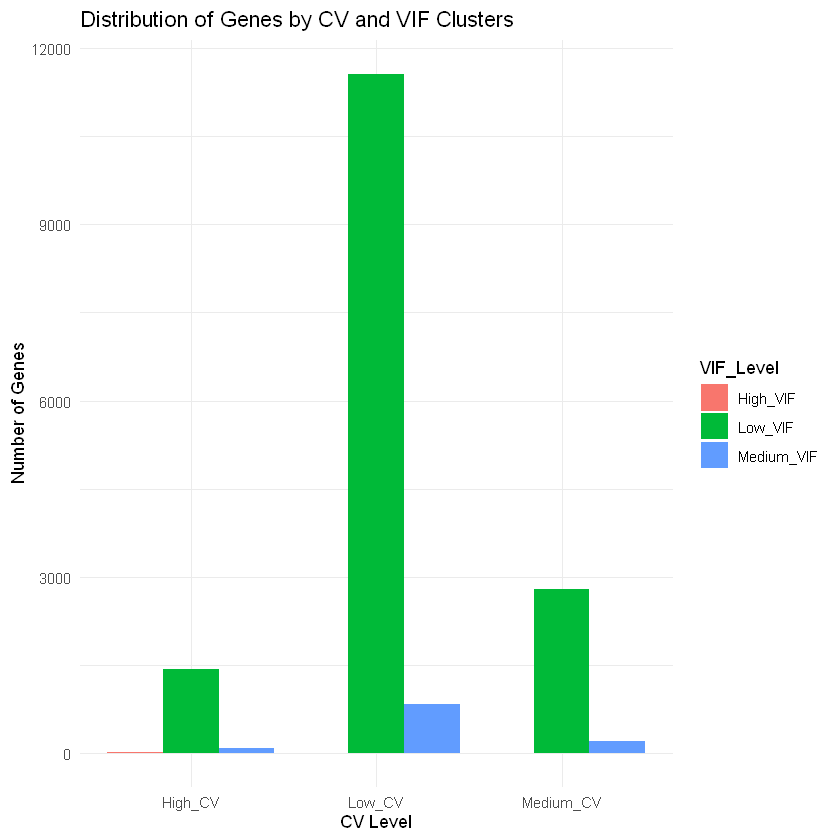

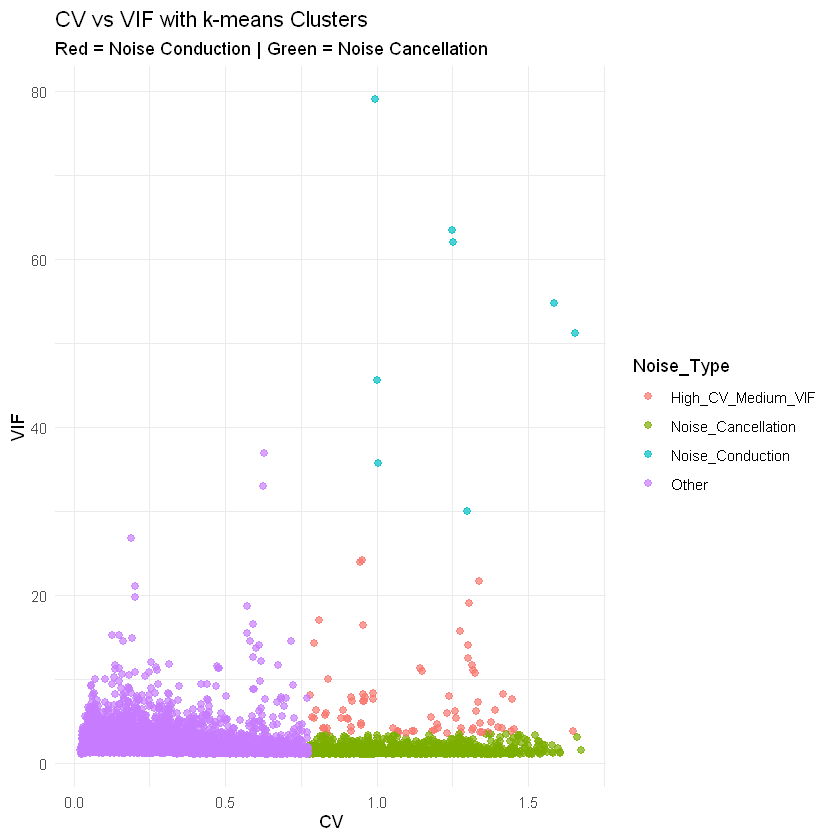

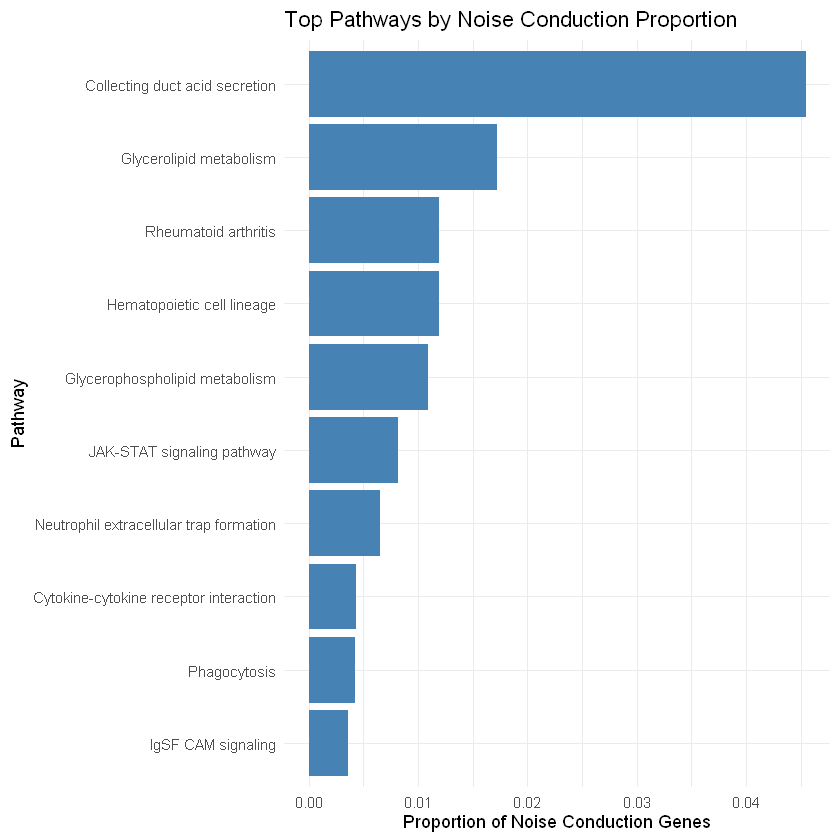

In [14]:
library(ggplot2)
library(dplyr)

# 1. Cluster Distribution
ggplot(final_vif_cv, aes(x = CV_Level, fill = VIF_Level)) +
  geom_bar(position = "dodge") +
  labs(title = "Distribution of Genes by CV and VIF Clusters",
       x = "CV Level", y = "Number of Genes") +
  theme_minimal()

# 2. Scatter plot CV vs VIF colored by Noise Type
ggplot(final_vif_cv, aes(x = CV, y = VIF, color = Noise_Type)) +
  geom_point(alpha = 0.7, size = 2) +
  labs(title = "CV vs VIF with k-means Clusters",
       subtitle = "Red = Noise Conduction | Green = Noise Cancellation") +
  theme_minimal()

# 3. Top Pathways bar plot (from pathway_summary)
ggplot(head(pathway_summary, 10), aes(x = reorder(Description, prop_Conduction), y = prop_Conduction)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top Pathways by Noise Conduction Proportion",
       x = "Pathway", y = "Proportion of Noise Conduction Genes") +
  theme_minimal()

In [15]:
ggsave("CV_VIF_Clusters.png", width = 8, height = 6)
ggsave("CV_vs_VIF_Scatter.png", width = 8, height = 6)
ggsave("Top_Noisy_Pathways.png", width = 10, height = 6)

In [16]:
save.image("LIHC_workspace.RData")

In [1]:
load("LIHC_workspace.RData")

# check what we have from k-means work
ls()

# load the gene cluster file
genes_clustered <- read.csv("LIHC_Genes_CV_VIF_Clusters.csv", 
                             stringsAsFactors = FALSE)
head(genes_clustered)
colnames(genes_clustered)

[1] "all_gene_ids"          "all_genes_ranked"      "all_vif_results"      
  [4] "amp_pathways"          "avg_cor"               "back_compare_results" 
  [7] "batch_data"            "batch_end"             "batch_genes"          
 [10] "batch_num"             "batch_result"          "batch_size"           
 [13] "biomarkers"            "cancellation_pathways" "clean_gene_names"     
 [16] "combined_summary"      "combined_table"        "cor_matrix"           
 [19] "cv_centers"            "cv_gene"               "cv_high_threshold"    
 [22] "cv_kmeans"             "cv_low_threshold"      "cv_matrix"            
 [25] "cv_partner"            "cv_table"              "cv_threshold"         
 [28] "cv_values"             "cytoscape_pathways"    "edges"                
 [31] "edges_clean"           "edges_final"           "edges_scored"         
 [34] "final_table"           "final_vif_cv"          "gene"                 
 [37] "gene_cors"             "gene_ids"              "gene_list"            
 [40] "gene_pathway_status"   "gene_symbols"          "heatmap_data"         
 [43] "heatmap_genes"         "high_cor"              "high_cv_threshold"    
 [46] "high_vif_cor"          "high_vif_expr"         "high_vif_genes"       
 [49] "i"                     "interesting_genes"     "keep"                 
 [52] "kegg_mapping"          "kegg_result"           "log_con"              
 [55] "low_cv_counts"         "low_cv_threshold"      "matched"              
 [58] "matched_all"           "model"                 "mrnaFiltered"         
 [61] "mrnaIDs"               "mrnaLog"               "mrnaMatrix"           
 [64] "mrnaNorm"              "mrnaTop"               "mrnaTop_reduced"      
 [67] "mrnaTop_t"             "n_batches"             "n_genes"              
 [70] "node_mapping"          "node_table"            "noisy_pathways"       
 [73] "partner"               "pathway_cv_vif"        "pathway_df"           
 [76] "pathway_gene_map"      "pathway_info"          "pathway_summary"      
 [79] "pathway_summary_named" "pct"                   "problematic"          
 [82] "response"              "top_genes"             "top_genes_cv"         
 [85] "top_idx"               "top_n"                 "top_partners"         
 [88] "top_pathways"          "top50_data"            "top50_genes"          
 [91] "vif_centers"           "vif_cv"                "vif_df"               
 [94] "vif_gene"              "vif_kmeans"            "vif_matrix"           
 [97] "vif_model"             "vif_results"           "vif_table"            
[100] "vif_values"

,Gene,VIF,CV,cv_cluster,vif_cluster,CV_Level,VIF_Level,Category
,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
1,64208,1.475953,1.674801,1,2,High_CV,Low_VIF,High_CV + Low_VIF
2,4747,3.118389,1.661146,1,2,High_CV,Low_VIF,High_CV + Low_VIF
3,84063,51.252273,1.655719,1,3,High_CV,High_VIF,High_CV + High_VIF
4,50632,3.746433,1.650261,1,1,High_CV,Medium_VIF,High_CV + Medium_VIF
5,93426,1.101744,1.606431,1,2,High_CV,Low_VIF,High_CV + Low_VIF
6,92737,1.227322,1.605572,1,2,High_CV,Low_VIF,High_CV + Low_VIF


[1] "Gene"        "VIF"         "CV"          "cv_cluster"  "vif_cluster"
[6] "CV_Level"    "VIF_Level"   "Category"

In [2]:
library(dplyr)

# add gene symbols
genes_clustered$Gene <- as.character(genes_clustered$Gene)
gene_symbols$ENTREZID <- as.character(gene_symbols$ENTREZID)

genes_clustered_named <- merge(genes_clustered, 
                                gene_symbols,
                                by.x = "Gene", by.y = "ENTREZID",
                                all.x = TRUE)

# check unique categories
unique(genes_clustered_named$Category)

# check CHGA is there
"CHGA" %in% genes_clustered_named$SYMBOL

# create simplified noise status column for Cytoscape
genes_clustered_named$noise_status_kmeans <- case_when(
  genes_clustered_named$Category == "High_CV + High_VIF" ~ "NOISE_CONDUCTION",
  genes_clustered_named$Category == "High_CV + Low_VIF" ~ "NOISE_CANCELLATION",
  genes_clustered_named$Category == "High_CV + Medium_VIF" ~ "NOISE_MODERATE",
  TRUE ~ "STABLE"
)

table(genes_clustered_named$noise_status_kmeans)

write.csv(genes_clustered_named,
          "LIHC_Genes_Kmeans_Named.csv",
          row.names = FALSE)

Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




[1] "Low_CV + Low_VIF"       "Medium_CV + Low_VIF"    "High_CV + Low_VIF"     
[4] "Low_CV + Medium_VIF"    "Medium_CV + Medium_VIF" "High_CV + Medium_VIF"  
[7] "High_CV + High_VIF"     "Medium_CV + High_VIF"   "Low_CV + High_VIF"

[1] TRUE


NOISE_CANCELLATION   NOISE_CONDUCTION     NOISE_MODERATE             STABLE 
              1434                  8                 79              15389 

In [3]:
# update noise status to cover all 9 categories
genes_clustered_named$noise_status_kmeans <- case_when(
  genes_clustered_named$Category == "High_CV + High_VIF" ~ "NOISE_CONDUCTION",
  genes_clustered_named$Category == "High_CV + Low_VIF"  ~ "NOISE_CANCELLATION",
  genes_clustered_named$Category == "High_CV + Medium_VIF" ~ "NOISE_MODERATE",
  genes_clustered_named$Category == "Medium_CV + High_VIF" ~ "NOISE_AMPLIFICATION",
  genes_clustered_named$Category == "Low_CV + High_VIF" ~ "NOISE_AMPLIFICATION",
  genes_clustered_named$Category == "Low_CV + Low_VIF" ~ "STABLE",
  genes_clustered_named$Category == "Low_CV + Medium_VIF" ~ "STABLE",
  genes_clustered_named$Category == "Medium_CV + Low_VIF" ~ "MODERATE",
  genes_clustered_named$Category == "Medium_CV + Medium_VIF" ~ "MODERATE",
  TRUE ~ "UNCLASSIFIED"
)

table(genes_clustered_named$noise_status_kmeans)

# save
write.csv(genes_clustered_named,
          "LIHC_Genes_Kmeans_Named.csv",
          row.names = FALSE)

save.image("LIHC_workspace.RData")


           MODERATE NOISE_AMPLIFICATION  NOISE_CANCELLATION    NOISE_CONDUCTION 
               2991                   3                1434                   8 
     NOISE_MODERATE              STABLE 
                 79               12395 

In [4]:
# who are the 8 noise conduction genes?
noise_conduction_kmeans <- genes_clustered_named %>%
  filter(noise_status_kmeans == "NOISE_CONDUCTION") %>%
  select(Gene, SYMBOL, CV, VIF, Category)

print(noise_conduction_kmeans)

    Gene  SYMBOL        CV      VIF           Category
1   1113    CHGA 1.5865653 54.72134 High_CV + High_VIF
2 196051   PLPP4 0.9956053 79.09231 High_CV + High_VIF
3 340706    VWA2 1.2974074 29.99361 High_CV + High_VIF
4   3589    IL11 1.0006447 45.55587 High_CV + High_VIF
5   4146   MATN1 1.0050439 35.76445 High_CV + High_VIF
6    566    AZU1 1.2517243 61.99737 High_CV + High_VIF
7   6521  SLC4A1 1.2494416 63.42352 High_CV + High_VIF
8  84063 KIRREL2 1.6557189 51.25227 High_CV + High_VIF


In [5]:
# save just the 8 key genes separately
write.csv(noise_conduction_kmeans,
          "LIHC_KMeans_Top8_NoiseConduction.csv",
          row.names = FALSE)

save.image("LIHC_workspace.RData")